# Reproduce thesis-discovered hybrid stacks and same-context singular benchmarks

This notebook reruns pruning and benchmarking for the frozen layer-wise policies
used in the thesis figures. It does **not** run LFPC discovery again. Instead it:

1. loads the ReduCNN package, data, and saved baselines in Colab/local runtimes;
2. reads the frozen thesis-stack manifest;
3. renders the layer-wise timelines for every stack;
4. scores every method needed by the hybrid stacks and every singular method in the same scope;
5. prunes each hybrid and each singular baseline at the exact dataset × model × objective × scope × ratio context;
6. heals every pruned model for `3` epochs;
7. saves pruned checkpoints, metrics, and comparison plots.

The comparison plots are produced from this fresh run, not borrowed from old
analysis CSVs.


## Colab bootloader and ReduCNN installation

Run this first on a fresh Colab GPU. It mounts Drive, finds the repository,
installs ReduCNN in editable mode, and verifies that `torch`, `torchvision`, and
the local package are importable. Set `REDUCNN_PROJECT_PATH` if the repository is
in a custom Drive location.


In [23]:
import importlib
import os
import subprocess
import sys
from pathlib import Path


def is_reducnn_repository(path):
    path = Path(path)
    return (path / "src" / "reducnn").is_dir() and (path / "pyproject.toml").is_file()


def locate_local_repository(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if is_reducnn_repository(candidate):
            return candidate
    return None


def locate_colab_repository():
    override = os.environ.get("REDUCNN_PROJECT_PATH", "").strip()
    candidates = [
        override,
        "/content/drive/Othercomputers/My laptop/activation-based-pruning",
        "/content/drive/MyDrive/activation-based-pruning",
        "/content/drive/.shortcut-targets-by-id",
    ]
    for candidate in candidates:
        if candidate and is_reducnn_repository(candidate):
            return Path(candidate).resolve()
    for root in [Path("/content/drive/.shortcut-targets-by-id"), Path("/content/drive/MyDrive"), Path("/content/drive/Othercomputers")]:
        if not root.exists():
            continue
        for current, directories, _files in os.walk(root):
            directories[:] = [d for d in directories if d not in {".git", "outputs", "__pycache__", "node_modules"}]
            if Path(current).name in {"activation-based-pruning", "activation-based-prunning"} and is_reducnn_repository(current):
                return Path(current).resolve()
    return None


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)
    PROJECT_ROOT = locate_colab_repository()
else:
    PROJECT_ROOT = locate_local_repository()

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate activation-based-pruning. Set REDUCNN_PROJECT_PATH.")

os.chdir(PROJECT_ROOT)
for path in (PROJECT_ROOT, PROJECT_ROOT / "src", PROJECT_ROOT / "ui"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

INSTALL_REDUCNN_PACKAGE = bool(globals().get("INSTALL_REDUCNN_PACKAGE", IN_COLAB))
REPRODUCTION_DRY_RUN = bool(globals().get("REPRODUCTION_DRY_RUN", os.environ.get("REDUCNN_REPRO_DRY_RUN", "0") == "1"))
if INSTALL_REDUCNN_PACKAGE and not REPRODUCTION_DRY_RUN:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(PROJECT_ROOT)], check=True)

if REPRODUCTION_DRY_RUN:
    print("Dry-run boot: skipping torch import and package installation.")
else:
    import torch
    import torchvision
    import reducnn
    print("PyTorch:", torch.__version__)
    print("torchvision:", torchvision.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("ReduCNN:", getattr(reducnn, "__version__", "unknown"), reducnn.__file__)

print("Project root:", PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA available: True
ReduCNN: 0.88.0 /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/src/reducnn/__init__.py
Project root: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning


## 1. User-editable run controls

Default behavior is resumable, not all-or-nothing. The notebook loads any
matching cached pruned artifact that already exists and prunes only the missing
hybrid/singular artifacts for the selected context. Set `FORCE_REPRUNE=True`
only when you intentionally want to recompute every selected cached artifact.

Useful context controls:

```python
EXECUTION_CONTEXT = "all"       # all | resnet_all | vgg16_all | resnet_local | resnet_global | vgg16_local | vgg16_global
RUN_DATASETS = ["cifar10"]      # optional subset; valid: cifar10, cats_dogs
RUN_MODELS = ["resnet18"]       # optional subset; valid: resnet18, vgg16
RUN_SCOPES = ["global"]         # optional subset; valid: local, global
RUN_OBJECTIVES = ["time_accuracy"]
RUN_RATIOS = [0.3, 0.45, 0.55]
STACK_IDS_TO_RUN = ["9000"]     # optional exact stack-id intersection
```

Edit the next code cell before running the notebook. Leave a value as `None`
to use the selected `EXECUTION_CONTEXT` preset.


In [24]:
# ============================================================
# User controls: choose exactly what to reproduce
# ============================================================
# The notebook is resumable by default: cached matching artifacts are reused,
# and only missing hybrid/singular prunes are computed.
# Options:
#   FORCE_REPRUNE = False  -> reuse matching cached checkpoints/metadata; prune only missing artifacts
#   FORCE_REPRUNE = True   -> recompute every selected hybrid and singular artifact
FORCE_REPRUNE = False

# Options:
#   True  -> benchmark same-context singular methods as well as hybrid stacks
#   False -> reproduce only the selected hybrid stacks
RUN_SINGULAR_BENCHMARKS = True

# EXECUTION_CONTEXT presets:
#   "all"              -> all frozen thesis stacks
#   "resnet_all"       -> ResNet18 stacks, both datasets, both scopes
#   "resnet18_all"     -> same as resnet_all
#   "vgg16_all"        -> VGG16 stacks, both datasets, both scopes
#   "vgg_all"          -> same as vgg16_all
#   "resnet_local"     -> ResNet18 local-scope stacks only
#   "resnet18_local"   -> same as resnet_local
#   "resnet_global"    -> ResNet18 global-scope stacks only
#   "resnet18_global"  -> same as resnet_global
#   "vgg16_local"      -> VGG16 local-scope stacks only
#   "vgg_local"        -> same as vgg16_local
#   "vgg16_global"     -> VGG16 global-scope stacks only
#   "vgg_global"       -> same as vgg16_global
EXECUTION_CONTEXT = "all"

# Optional exact filters. Use None to inherit from EXECUTION_CONTEXT.
# Valid RUN_DATASETS:
#   None, ["cifar10"], ["cats_dogs"], ["cifar10", "cats_dogs"]
RUN_DATASETS = None

# Valid RUN_MODELS:
#   None, ["resnet18"], ["vgg16"], ["resnet18", "vgg16"]
RUN_MODELS = None

# Valid RUN_SCOPES:
#   None, ["local"], ["global"], ["local", "global"]
RUN_SCOPES = None

# Valid RUN_OBJECTIVES:
#   None, ["flops_accuracy"], ["time_accuracy"], ["all_three"]
#   or any list combination, e.g. ["flops_accuracy", "time_accuracy"]
RUN_OBJECTIVES = None

# Valid RUN_RATIOS:
#   None, [0.3], [0.45], [0.55], or combinations such as [0.3, 0.45, 0.55]
# The manifest may also include a small number of frozen local cases at other ratios
# if they were explicitly used in the thesis figures.
RUN_RATIOS = None

# Valid STACK_IDS_TO_RUN:
#   None -> all stacks matching the context filters
#   or a list of frozen thesis stack ids:
#   ["9000", "9738", "3583", "7910", "6256", "8802",
#    "3265", "6068", "5122", "8196", "4330", "8862",
#    "6755", "6619", "5063", "1473", "7774"]
STACK_IDS_TO_RUN = None

# Healing and baseline controls.
# HEALING_EPOCHS:
#   integer >= 0; thesis reproduction default is 3
# HEALING_TRAIN_BATCHES:
#   None for full healing loader, or a positive integer cap such as 30
# HEALING_VAL_BATCHES:
#   None for full validation loader, or a positive integer cap for faster checks
HEALING_EPOCHS = 3
HEALING_TRAIN_BATCHES = 30
HEALING_VAL_BATCHES = None

# Cats-vs-Dogs baseline controls:
#   CATDOG_BASELINE_EPOCHS: integer >= 1, used only if a usable baseline is missing
#   CATDOG_BASELINE_MIN_ACC: minimum acceptable validation/test accuracy percentage
#   FORCE_RETRAIN_CATDOG_BASELINE:
#       False -> load an acceptable saved baseline if found
#       True  -> retrain Cats-vs-Dogs baseline before pruning
CATDOG_BASELINE_EPOCHS = 3
CATDOG_BASELINE_MIN_ACC = 70.0
FORCE_RETRAIN_CATDOG_BASELINE = False

# Runtime controls mirrored from the LFPC objective notebooks.
# Leave as None to use dataset/model defaults.
# SCORING_CALIB_BATCHES:
#   None for context defaults, or positive integer; lower is faster but noisier
SCORING_CALIB_BATCHES = None

# HEAVY_METHOD_BATCHES:
#   None for context defaults, or positive integer cap for expensive methods
#   such as CHIP, ThiNet, NISP, DCP, GFS, AutoDFP, TIS, and SeNPIS.
HEAVY_METHOD_BATCHES = None

# SCORING_BATCH_SIZE:
#   None for dataset defaults, or positive integer if GPU memory allows.
SCORING_BATCH_SIZE = None

# EVAL_MAX_BATCHES:
#   None for full evaluation, or positive integer for quick smoke tests.
EVAL_MAX_BATCHES = None

# BASELINE_EVAL_MAX_BATCHES / BENCHMARK_EVAL_MAX_BATCHES:
#   None inherits EVAL_MAX_BATCHES; otherwise use a positive integer cap.
BASELINE_EVAL_MAX_BATCHES = None
BENCHMARK_EVAL_MAX_BATCHES = None

# COST_MEASUREMENT_RUNS:
#   integer >= 1; use 1 for thesis reproduction speed unless profiling runtime variance.
COST_MEASUREMENT_RUNS = 1

# Optional method-specific scoring overrides, for example:
# METHOD_SCORING_BATCHES = {"chip": 1}
# METHOD_CHIP_MAX_SPATIAL = {"chip": 256}
# Valid keys are registered method ids, e.g.:
#   "l1_norm", "custom_l2", "mean_abs_act", "apoz", "custom_entropy",
#   "custom_class_entropy", "custom_hrank", "custom_spectral_energy",
#   "custom_gfi_ap", "chip", "custom_reprune", "custom_nisp",
#   "custom_senpis", "custom_tis", "custom_thinet", "custom_gfs",
#   "custom_dcp", "custom_autodfp"
METHOD_SCORING_BATCHES = {}
METHOD_CHIP_MAX_SPATIAL = {}

print("Run controls configured:")
print("  EXECUTION_CONTEXT =", EXECUTION_CONTEXT)
print("  RUN_DATASETS =", RUN_DATASETS)
print("  RUN_MODELS =", RUN_MODELS)
print("  RUN_SCOPES =", RUN_SCOPES)
print("  RUN_OBJECTIVES =", RUN_OBJECTIVES)
print("  RUN_RATIOS =", RUN_RATIOS)
print("  STACK_IDS_TO_RUN =", STACK_IDS_TO_RUN)
print("  FORCE_REPRUNE =", FORCE_REPRUNE)


Run controls configured:
  EXECUTION_CONTEXT = all
  RUN_DATASETS = None
  RUN_MODELS = None
  RUN_SCOPES = None
  RUN_OBJECTIVES = None
  RUN_RATIOS = None
  STACK_IDS_TO_RUN = None
  FORCE_REPRUNE = False


## Runtime setup

The next cell resolves the controls above, creates the output/cache
directories, and filters the frozen thesis-stack manifest.


In [25]:
import copy
import json
import os
import random
import re
import time
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _runtime_value(name, aliases=(), default=None):
    """Resolve an editable notebook value, aliases, then environment variables."""
    for key in (name, *tuple(aliases)):
        if key in globals() and globals()[key] not in (None, ""):
            return globals()[key]
    for key in (name, *tuple(aliases)):
        value = os.environ.get(key, None)
        if value not in (None, ""):
            return value
    return default

def _truthy(value, default=False):
    if value is None:
        return default
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}

ROOT = Path(PROJECT_ROOT).resolve()
MANIFEST_PATH = ROOT / "configs" / "thesis_discovered_stack_reproduction_manifest.json"
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_ROOT = ROOT / "outputs" / "thesis_stack_reproduction"
CACHE_ROOT = OUTPUT_ROOT / "artifact_cache"
CACHE_SCHEMA_VERSION = "3_catdog_shuffled_split_baseline_gate"
RUN_DIR = OUTPUT_ROOT / RUN_STAMP
PLOT_DIR = RUN_DIR / "comparison_plots"
TIMELINE_DIR = RUN_DIR / "policy_timelines"
MODEL_DIR = RUN_DIR / "saved_pruned_models"
for path in [RUN_DIR, PLOT_DIR, TIMELINE_DIR, MODEL_DIR, CACHE_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

SEED = int(_runtime_value("SEED", default=42))
random.seed(SEED)
np.random.seed(SEED)

FORCE_REPRUNE = _truthy(_runtime_value("FORCE_REPRUNE", default=False))
RUN_SINGULAR_BENCHMARKS = _truthy(_runtime_value("RUN_SINGULAR_BENCHMARKS", default=True), default=True)
HEALING_EPOCHS = int(_runtime_value("HEALING_EPOCHS", default=3))
STACK_IDS_TO_RUN = _runtime_value("STACK_IDS_TO_RUN")
EXECUTION_CONTEXT = str(_runtime_value("EXECUTION_CONTEXT", default="all")).strip().lower()
RUN_DATASETS = _runtime_value("RUN_DATASETS", aliases=("DATASETS_TO_RUN",))
RUN_MODELS = _runtime_value("RUN_MODELS", aliases=("MODELS_TO_RUN",))
RUN_SCOPES = _runtime_value("RUN_SCOPES", aliases=("SCOPES_TO_RUN",))
RUN_OBJECTIVES = _runtime_value("RUN_OBJECTIVES", aliases=("OBJECTIVES_TO_RUN",))
RUN_RATIOS = _runtime_value("RUN_RATIOS", aliases=("RATIOS_TO_RUN",))

# Runtime controls mirrored from the LFPC objective notebooks.
# Leave these as None to use the per-dataset/model defaults below, or override
# them in Colab before running the notebook.
SCORING_CALIB_BATCHES_OVERRIDE = _runtime_value("SCORING_CALIB_BATCHES")
HEAVY_METHOD_BATCHES_OVERRIDE = _runtime_value("HEAVY_METHOD_BATCHES")
COST_MEASUREMENT_RUNS = int(_runtime_value("COST_MEASUREMENT_RUNS", default=1))
SCORING_BATCH_SIZE_OVERRIDE = _runtime_value("SCORING_BATCH_SIZE")
EVAL_MAX_BATCHES_OVERRIDE = _runtime_value("EVAL_MAX_BATCHES")
BASELINE_EVAL_MAX_BATCHES = _runtime_value("BASELINE_EVAL_MAX_BATCHES", default=EVAL_MAX_BATCHES_OVERRIDE)
BENCHMARK_EVAL_MAX_BATCHES = _runtime_value("BENCHMARK_EVAL_MAX_BATCHES", default=EVAL_MAX_BATCHES_OVERRIDE)
HEALING_TRAIN_BATCHES = int(_runtime_value("HEALING_TRAIN_BATCHES", default=30))
HEALING_VAL_BATCHES_OVERRIDE = _runtime_value("HEALING_VAL_BATCHES")
CATDOG_BASELINE_EPOCHS = int(_runtime_value("CATDOG_BASELINE_EPOCHS", default=3))
CATDOG_BASELINE_MIN_ACC = float(_runtime_value("CATDOG_BASELINE_MIN_ACC", default=70.0))
FORCE_RETRAIN_CATDOG_BASELINE = _truthy(_runtime_value("FORCE_RETRAIN_CATDOG_BASELINE", default=False))
METHOD_SCORING_BATCHES = dict(_runtime_value("METHOD_SCORING_BATCHES", default={}))
METHOD_CHIP_MAX_SPATIAL = dict(_runtime_value("METHOD_CHIP_MAX_SPATIAL", default={}))
DEFAULT_HEAVY_METHODS = {
    "chip", "custom_senpis", "custom_thinet", "custom_gfi_ap", "custom_gfs",
    "custom_dcp", "custom_autodfp", "custom_tis", "custom_nisp",
}

manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
stacks = manifest["stacks"]

def _as_filter_set(value, normalizer=str):
    if value is None or value == "" or value == "all" or value == ["all"]:
        return None
    if isinstance(value, str):
        text = value.strip()
        if text.lower() == "all":
            return None
        if text.startswith(("[", "(", "{")):
            try:
                import ast
                parsed = ast.literal_eval(text)
                if isinstance(parsed, (list, tuple, set)):
                    parts = list(parsed)
                else:
                    parts = [parsed]
            except Exception:
                parts = [x.strip().strip("'\"[](){}") for x in re.split(r"[,| ]+", text) if x.strip()]
        else:
            parts = [x.strip().strip("'\"[](){}") for x in re.split(r"[,| ]+", text) if x.strip()]
    else:
        parts = list(value)
    out = {normalizer(x) for x in parts}
    out.discard("")
    out.discard("all")
    return out or None

def _norm_dataset(value):
    text = str(value).strip().lower().replace("-", "_")
    aliases = {"cifar_10": "cifar10", "catsdogs": "cats_dogs", "cat_dogs": "cats_dogs", "cats_vs_dogs": "cats_dogs"}
    return aliases.get(text, text)

def _norm_model(value):
    text = str(value).strip().lower().replace("-", "")
    aliases = {"resnet": "resnet18", "rn18": "resnet18", "vgg": "vgg16"}
    return aliases.get(text, text)

def _norm_scope(value):
    return str(value).strip().lower()

def _norm_objective(value):
    return str(value).strip().lower().replace(" + ", "_").replace("+", "_").replace("-", "_").replace(" ", "_")

def _norm_ratio(value):
    return round(float(value), 6)

context_presets = {
    "all": {},
    "resnet_all": {"models": {"resnet18"}},
    "resnet18_all": {"models": {"resnet18"}},
    "vgg16_all": {"models": {"vgg16"}},
    "vgg_all": {"models": {"vgg16"}},
    "resnet_local": {"models": {"resnet18"}, "scopes": {"local"}},
    "resnet18_local": {"models": {"resnet18"}, "scopes": {"local"}},
    "resnet_global": {"models": {"resnet18"}, "scopes": {"global"}},
    "resnet18_global": {"models": {"resnet18"}, "scopes": {"global"}},
    "vgg16_local": {"models": {"vgg16"}, "scopes": {"local"}},
    "vgg_local": {"models": {"vgg16"}, "scopes": {"local"}},
    "vgg16_global": {"models": {"vgg16"}, "scopes": {"global"}},
    "vgg_global": {"models": {"vgg16"}, "scopes": {"global"}},
}
if EXECUTION_CONTEXT not in context_presets:
    raise ValueError(f"Unknown EXECUTION_CONTEXT={EXECUTION_CONTEXT!r}. Valid presets: {sorted(context_presets)}")

preset = context_presets[EXECUTION_CONTEXT]
dataset_filter = _as_filter_set(RUN_DATASETS, _norm_dataset)
model_filter = _as_filter_set(RUN_MODELS, _norm_model) or preset.get("models")
scope_filter = _as_filter_set(RUN_SCOPES, _norm_scope) or preset.get("scopes")
objective_filter = _as_filter_set(RUN_OBJECTIVES, _norm_objective)
ratio_filter = _as_filter_set(RUN_RATIOS, _norm_ratio)
stack_id_filter = _as_filter_set(STACK_IDS_TO_RUN, lambda x: str(x).strip())

if stack_id_filter is not None:
    stacks = [s for s in stacks if str(s["stack_id"]) in stack_id_filter]
if dataset_filter is not None:
    stacks = [s for s in stacks if _norm_dataset(s["dataset"]) in dataset_filter]
if model_filter is not None:
    stacks = [s for s in stacks if _norm_model(s["model"]) in model_filter]
if scope_filter is not None:
    stacks = [s for s in stacks if _norm_scope(s["scope"]) in scope_filter]
if objective_filter is not None:
    stacks = [s for s in stacks if _norm_objective(s["objective"]) in objective_filter]
if ratio_filter is not None:
    stacks = [s for s in stacks if _norm_ratio(s["ratio"]) in ratio_filter]
if not stacks:
    raise RuntimeError(
        "No frozen stacks selected after context filters. "
        f"EXECUTION_CONTEXT={EXECUTION_CONTEXT}, datasets={dataset_filter}, models={model_filter}, "
        f"scopes={scope_filter}, objectives={objective_filter}, ratios={ratio_filter}, STACK_IDS_TO_RUN={STACK_IDS_TO_RUN}"
    )

print("Manifest:", MANIFEST_PATH)
print("Output:", RUN_DIR)
print("Reusable artifact cache:", CACHE_ROOT)
print("Stacks:", [s["stack_id"] for s in stacks])
print("Execution context preset:", EXECUTION_CONTEXT)
print("Context filters:", {
    "datasets": sorted(dataset_filter) if dataset_filter else "all",
    "models": sorted(model_filter) if model_filter else "all",
    "scopes": sorted(scope_filter) if scope_filter else "all",
    "objectives": sorted(objective_filter) if objective_filter else "all",
    "ratios": sorted(ratio_filter) if ratio_filter else "all",
    "stack_ids": sorted(stack_id_filter) if stack_id_filter else "all",
})
print("Force reprune:", FORCE_REPRUNE)
print("Healing epochs:", HEALING_EPOCHS)
print("Healing train/val batch caps:", HEALING_TRAIN_BATCHES, HEALING_VAL_BATCHES_OVERRIDE)
print("Cats/Dogs baseline epochs/min accuracy:", CATDOG_BASELINE_EPOCHS, CATDOG_BASELINE_MIN_ACC)
print("Scoring calib override:", SCORING_CALIB_BATCHES_OVERRIDE)
print("Heavy-method batch override:", HEAVY_METHOD_BATCHES_OVERRIDE)
print("Eval max batches:", EVAL_MAX_BATCHES_OVERRIDE)
print("Method scoring overrides:", METHOD_SCORING_BATCHES)
print("Method CHIP spatial overrides:", METHOD_CHIP_MAX_SPATIAL)


Manifest: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/configs/thesis_discovered_stack_reproduction_manifest.json
Output: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/20260616_182911
Reusable artifact cache: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache
Stacks: ['9000', '9738', '3583', '7910', '6256', '8802', '3265', '6068', '5122', '8196', '4330', '8862', '6755', '6619', '5063', '1473', '7774']
Execution context preset: all
Context filters: {'datasets': 'all', 'models': 'all', 'scopes': 'all', 'objectives': 'all', 'ratios': 'all', 'stack_ids': 'all'}
Force reprune: False
Healing epochs: 3
Healing train/val batch caps: 30 None
Cats/Dogs baseline epochs/min accuracy: 3 70.0
Scoring calib override: None
Heavy-method batch override: None
Eval max batch

## Validate and display frozen stack manifest

This cell is the first context audit. Each stack must have a known dataset,
model, scope, objective, pruning ratio, and a complete layer-wise method policy.


In [26]:
MIN_EXPECTED_LAYERS = {"resnet18": 18, "vgg16": 13}
VALID_LOCAL_METHODS_FOR_SCOPE_AUDIT = {
    "l1_norm", "custom_l2", "mean_abs_act", "apoz", "custom_entropy",
    "custom_gfi_ap", "custom_class_entropy", "custom_hrank", "custom_spectral_energy",
}
VALID_GLOBAL_METHODS_FOR_SCOPE_AUDIT = {
    "chip", "custom_reprune", "custom_nisp", "custom_senpis", "custom_tis",
    "custom_thinet", "custom_gfs", "custom_dcp", "custom_autodfp",
}

def _valid_methods_for_scope_audit(scope):
    scope = str(scope).lower().strip()
    if scope == "local":
        return VALID_LOCAL_METHODS_FOR_SCOPE_AUDIT
    if scope == "global":
        return VALID_GLOBAL_METHODS_FOR_SCOPE_AUDIT
    raise ValueError(f"Unsupported scope {scope!r}; expected local or global.")

policy_rows = []
for stack in stacks:
    sid = str(stack["stack_id"])
    model = str(stack["model"]).lower()
    allowed_scope_methods = _valid_methods_for_scope_audit(stack["scope"])
    if model not in MIN_EXPECTED_LAYERS:
        raise ValueError(f"Unsupported model for stack {sid}: {model}")
    if len(stack["policy"]) < MIN_EXPECTED_LAYERS[model]:
        raise RuntimeError(
            f"Stack {sid} has only {len(stack['policy'])} layers; expected at least "
            f"{MIN_EXPECTED_LAYERS[model]} for a complete discovered {model} policy."
        )
    if not 0 < float(stack["ratio"]) < 1:
        raise ValueError(f"Invalid pruning ratio for stack {sid}: {stack['ratio']}")
    names = [layer for layer, _method in stack["policy"]]
    if len(names) != len(set(names)):
        raise RuntimeError(f"Duplicate layer assignment in stack {sid}.")
    bad_methods = sorted({str(method) for _layer, method in stack["policy"] if str(method) not in allowed_scope_methods})
    if bad_methods:
        raise RuntimeError(
            f"Scope violation in frozen stack {sid}: scope={stack['scope']!r} but policy contains "
            f"methods outside that scope: {bad_methods}. Local stacks must use only local criteria; "
            "global stacks must use only global pruning methods."
        )
    for i, (layer, method) in enumerate(stack["policy"], start=1):
        n = len(stack["policy"])
        region = "Early" if i <= int(np.ceil(n / 3)) else "Middle" if i <= int(np.ceil(2 * n / 3)) else "Late"
        policy_rows.append({
            "stack_id": sid,
            "dataset": stack["dataset"],
            "dataset_label": stack["dataset_label"],
            "objective": stack["objective"],
            "objective_label": stack["objective_label"],
            "model": model,
            "scope": stack["scope"],
            "ratio": float(stack["ratio"]),
            "context_rank": stack.get("context_rank"),
            "layer_index": i,
            "region": region,
            "layer": layer,
            "selected_method": method,
        })

policy_df = pd.DataFrame(policy_rows)
policy_df.to_csv(RUN_DIR / "frozen_layerwise_policies.csv", index=False)
display(policy_df)


,stack_id,dataset,dataset_label,objective,objective_label,model,scope,ratio,context_rank,layer_index,region,layer,selected_method
0,9000,cifar10,CIFAR-10,flops_accuracy,FLOPs + Accuracy,resnet18,global,0.3,2,1,Early,conv1,custom_thinet
1,9000,cifar10,CIFAR-10,flops_accuracy,FLOPs + Accuracy,resnet18,global,0.3,2,2,Early,layer1.0.conv1,custom_reprune
2,9000,cifar10,CIFAR-10,flops_accuracy,FLOPs + Accuracy,resnet18,global,0.3,2,3,Early,layer1.0.conv2,custom_tis
3,9000,cifar10,CIFAR-10,flops_accuracy,FLOPs + Accuracy,resnet18,global,0.3,2,4,Early,layer1.1.conv1,custom_autodfp
4,9000,cifar10,CIFAR-10,flops_accuracy,FLOPs + Accuracy,resnet18,global,0.3,2,5,Early,layer1.1.conv2,custom_tis
...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,7774,cats_dogs,Cats-vs-Dogs,time_accuracy,Time + Accuracy,vgg16,local,0.3,1,11,Late,features.24,custom_l2
281,7774,cats_dogs,Cats-vs-Dogs,time_accuracy,Time + Accuracy,vgg16,local,0.3,1,12,Late,features.26,custom_entropy
282,7774,cats_dogs,Cats-vs-Dogs,time_accuracy,Time + Accuracy,vgg16,local,0.3,1,13,Late,features.28,custom_entropy
283,7774,cats_dogs,Cats-vs-Dogs,time_accuracy,Time + Accuracy,vgg16,local,0.3,1,14,Late,classifier.0,custom_hrank


## Layer-wise policy timelines


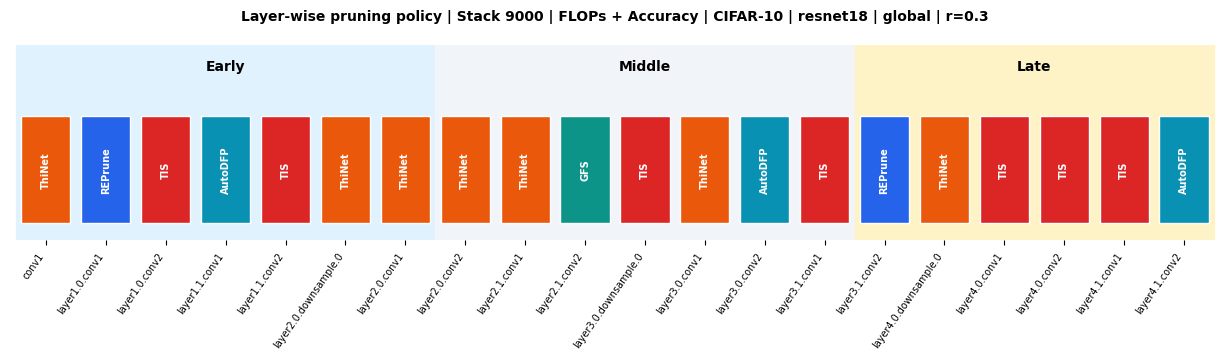

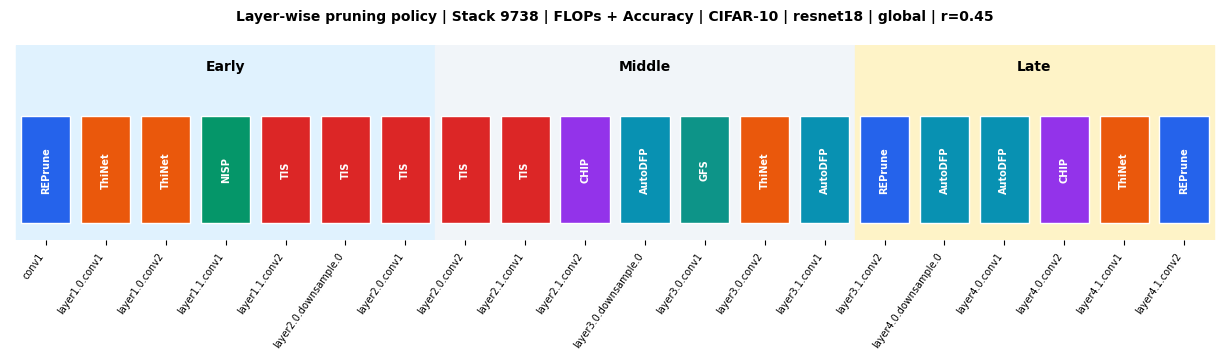

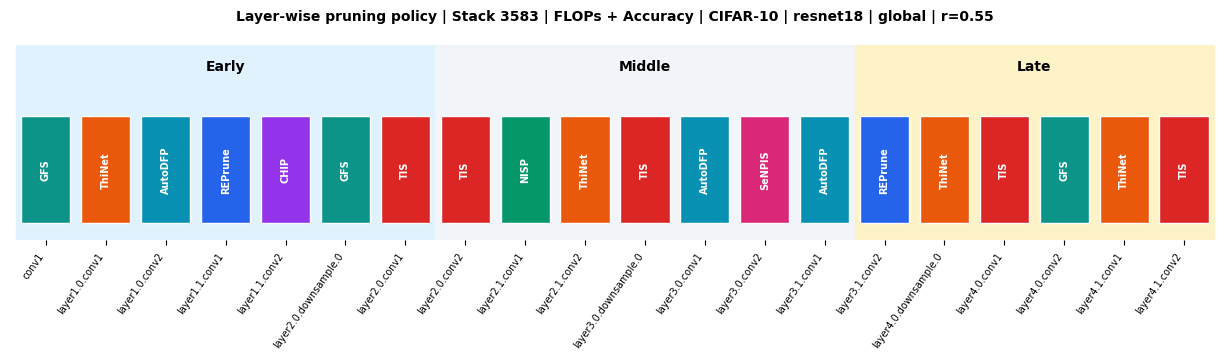

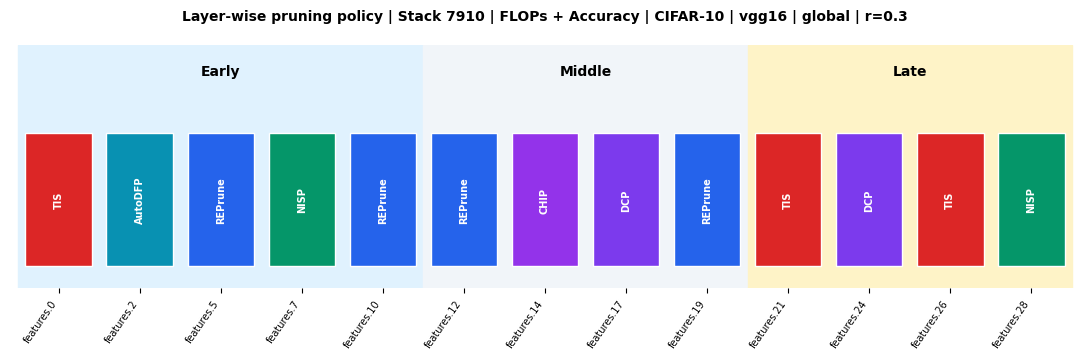

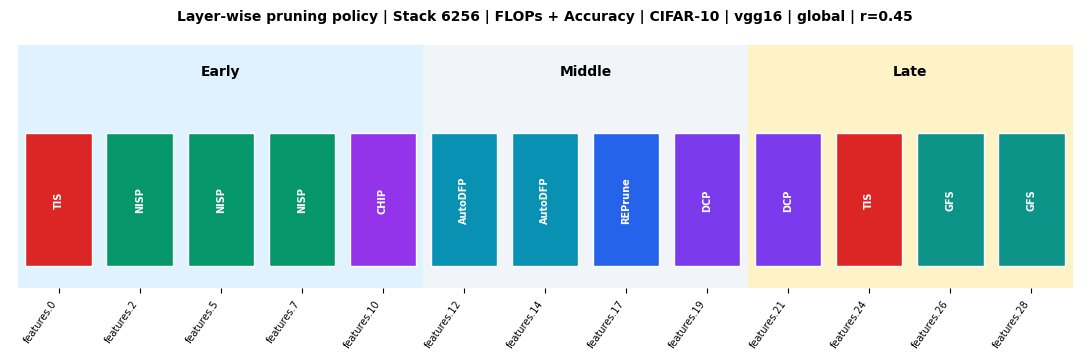

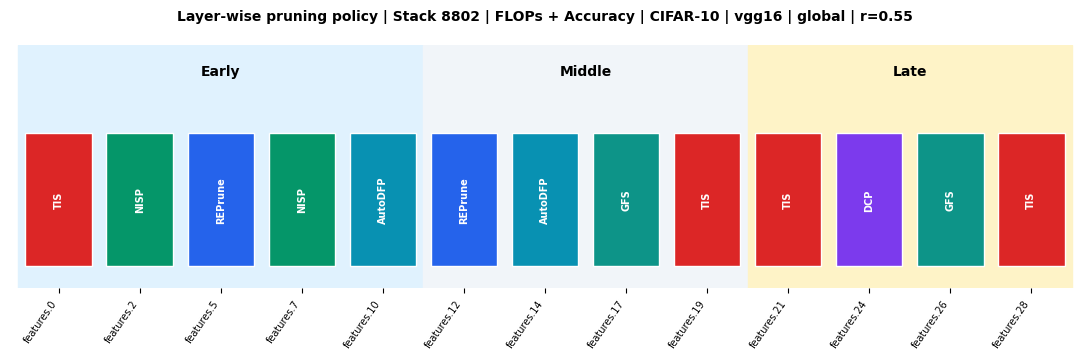

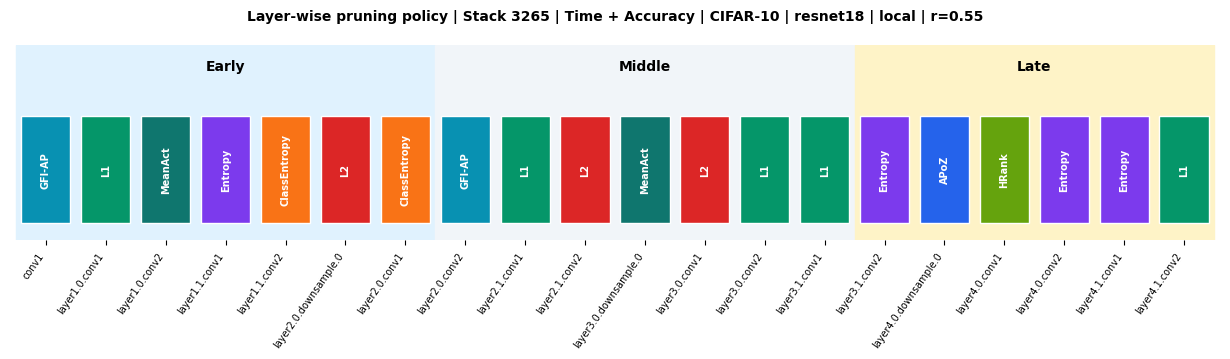

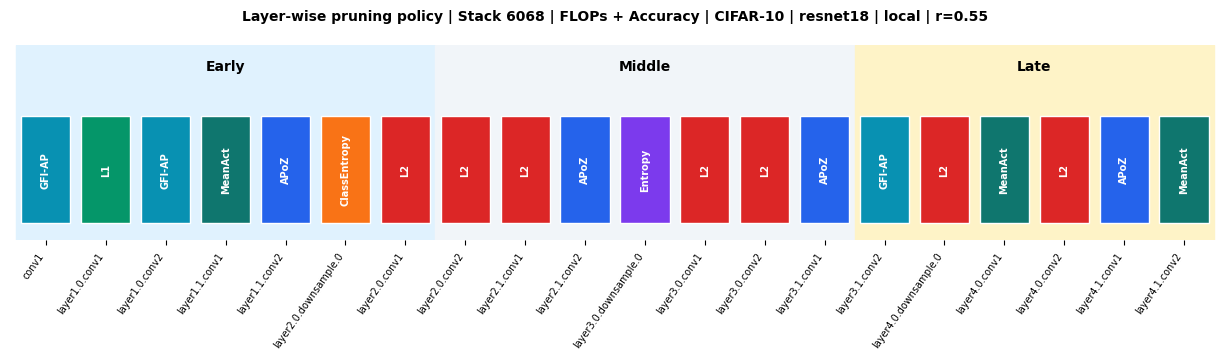

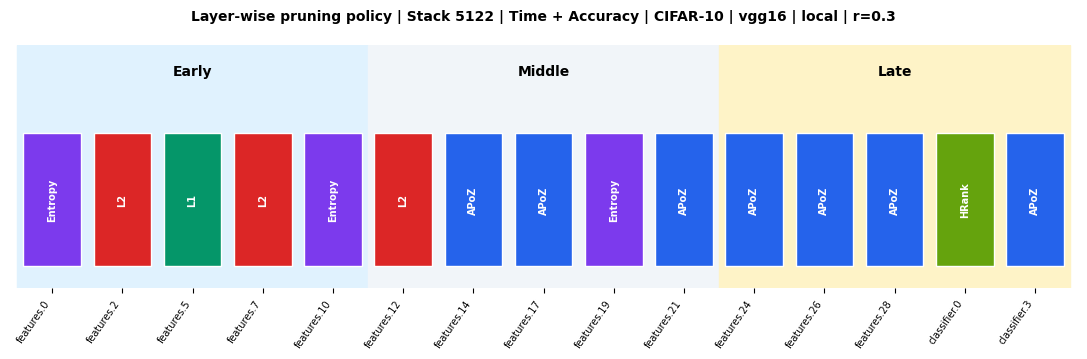

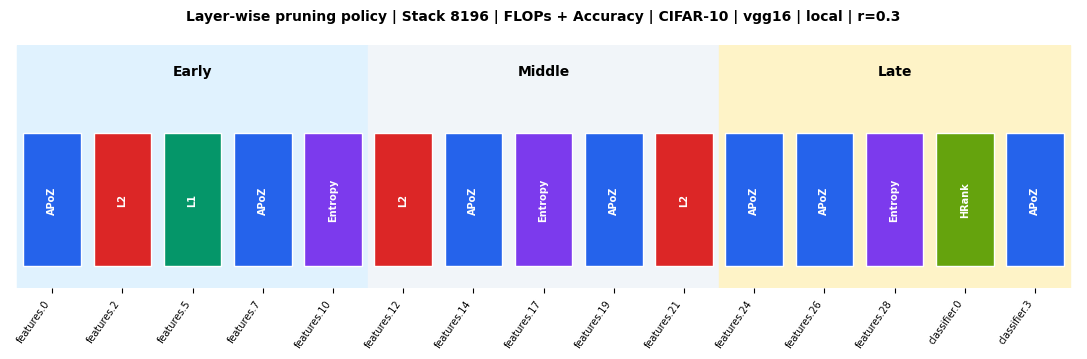

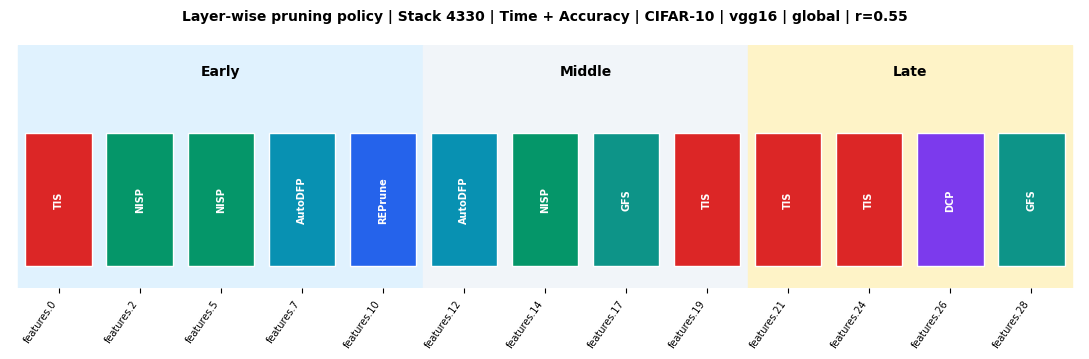

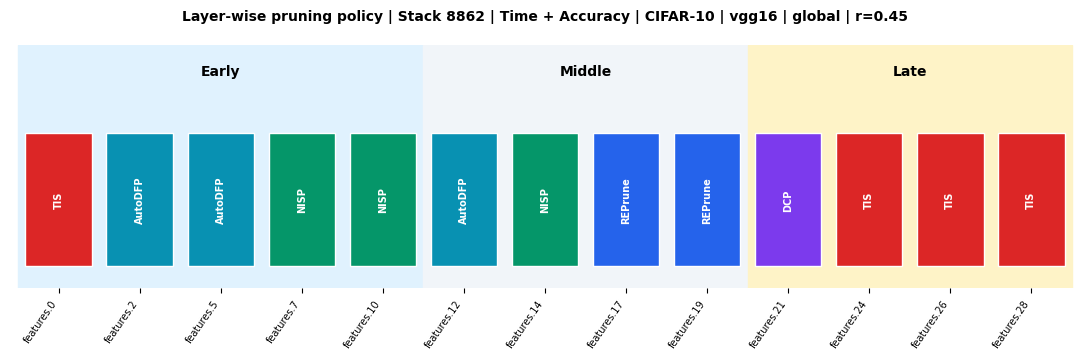

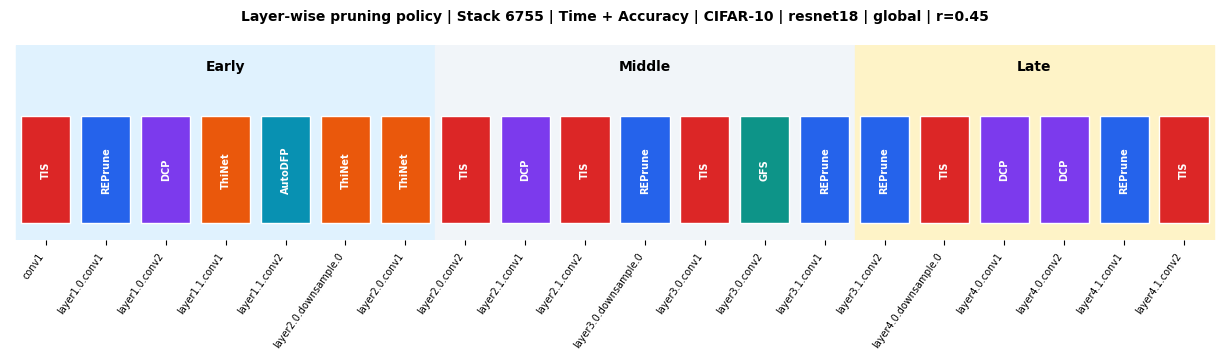

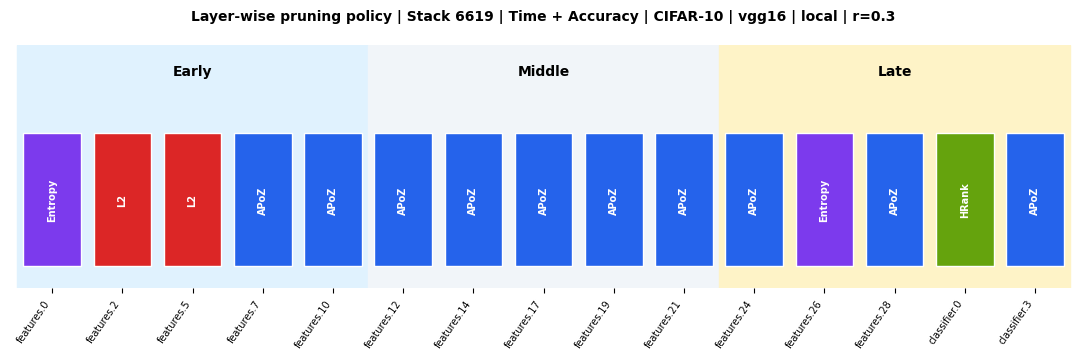

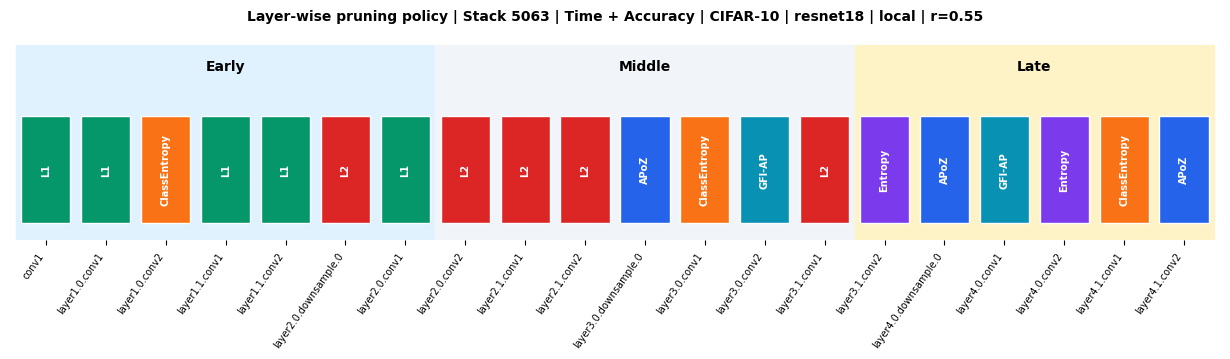

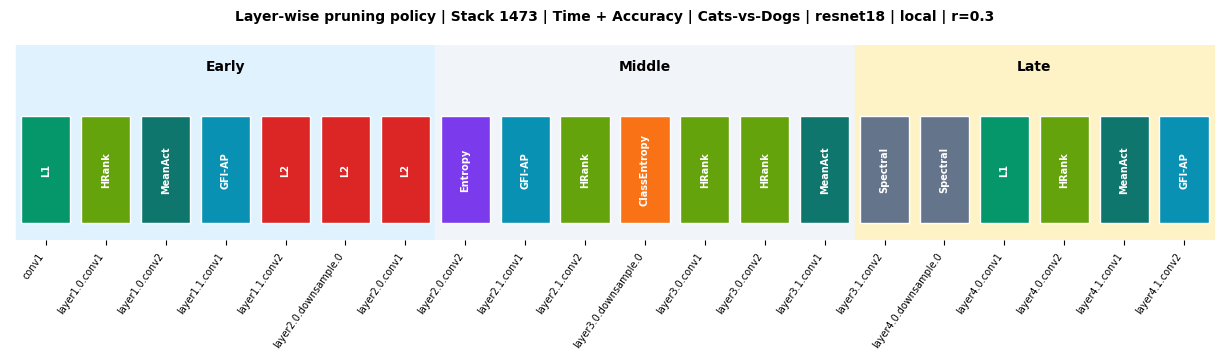

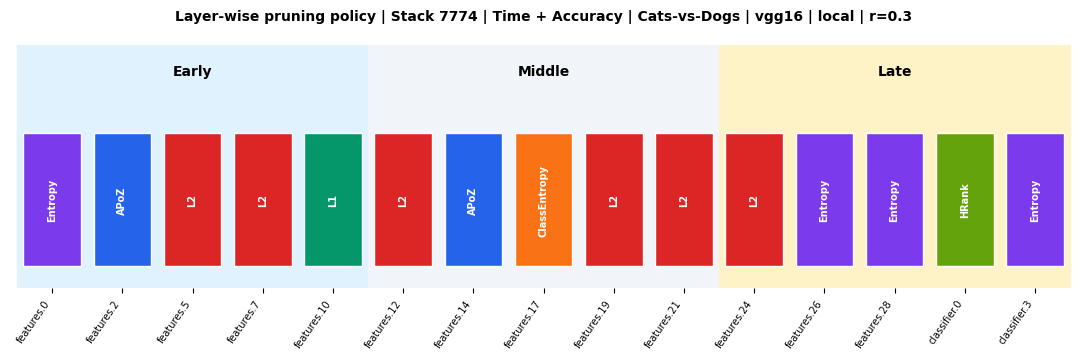

In [27]:
METHOD_LABELS = {
    "l1_norm": "L1", "custom_l2": "L2", "mean_abs_act": "MeanAct", "apoz": "APoZ",
    "custom_entropy": "Entropy", "custom_class_entropy": "ClassEntropy", "custom_hrank": "HRank",
    "custom_spectral_energy": "Spectral", "custom_gfi_ap": "GFI-AP",
    "chip": "CHIP", "custom_reprune": "REPrune", "custom_nisp": "NISP",
    "custom_senpis": "SeNPIS", "custom_tis": "TIS", "custom_thinet": "ThiNet",
    "custom_gfs": "GFS", "custom_dcp": "DCP", "custom_autodfp": "AutoDFP",
}
METHOD_COLORS = {
    "l1_norm": "#059669", "custom_l2": "#DC2626", "mean_abs_act": "#0F766E", "apoz": "#2563EB",
    "custom_entropy": "#7C3AED", "custom_class_entropy": "#F97316", "custom_hrank": "#65A30D",
    "custom_spectral_energy": "#64748B", "custom_gfi_ap": "#0891B2",
    "chip": "#9333EA", "custom_reprune": "#2563EB", "custom_nisp": "#059669",
    "custom_senpis": "#DB2777", "custom_tis": "#DC2626", "custom_thinet": "#EA580C",
    "custom_gfs": "#0D9488", "custom_dcp": "#7C3AED", "custom_autodfp": "#0891B2",
}

def plot_policy_timeline(stack):
    rows = policy_df[policy_df["stack_id"].astype(str) == str(stack["stack_id"])].sort_values("layer_index")
    count = len(rows)
    x = np.arange(count)
    fig, ax = plt.subplots(figsize=(max(11, count * 0.62), 3.7))
    bounds = [0, int(np.ceil(count / 3)), int(np.ceil(2 * count / 3)), count]
    for idx, (label, color) in enumerate([("Early", "#E0F2FE"), ("Middle", "#F1F5F9"), ("Late", "#FEF3C7")]):
        left, right = bounds[idx], bounds[idx + 1]
        ax.axvspan(left - 0.5, right - 0.5, color=color, zorder=0)
        ax.text((left + right - 1) / 2, 1.18, label, ha="center", va="center", fontsize=10, fontweight="bold")
    for pos, row in enumerate(rows.itertuples()):
        method = row.selected_method
        ax.bar(pos, 0.72, bottom=0.12, width=0.82, color=METHOD_COLORS.get(method, "#475569"), edgecolor="white")
        ax.text(pos, 0.48, METHOD_LABELS.get(method, method), ha="center", va="center", rotation=90,
                fontsize=7, color="white", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(rows["layer"].astype(str), rotation=55, ha="right", fontsize=7)
    ax.set_yticks([])
    ax.set_ylim(0, 1.32)
    ax.set_xlim(-0.6, count - 0.4)
    ax.set_title(
        f"Layer-wise pruning policy | Stack {stack['stack_id']} | {stack['objective_label']} | "
        f"{stack['dataset_label']} | {stack['model']} | {stack['scope']} | r={float(stack['ratio']):g}",
        fontsize=10, fontweight="bold", pad=18,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.tight_layout()
    path = TIMELINE_DIR / f"timeline_{stack['stack_id']}_{stack['dataset']}_{stack['model']}_{stack['scope']}_r{float(stack['ratio']):g}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return str(path)

timeline_rows = [{"stack_id": stack["stack_id"], "plot": plot_policy_timeline(stack)} for stack in stacks]
pd.DataFrame(timeline_rows).to_csv(RUN_DIR / "policy_timeline_index.csv", index=False)


## 5. Register ReduCNN pruning methods

This is the method-registration section. It should **not** contain the run
selection controls above. If it does, regenerate the notebook from
`scripts/build_thesis_stack_reproduction_notebook.py`.


In [28]:
# ============================================================
# Method registration: base/UI ReduCNN methods
# ============================================================
if REPRODUCTION_DRY_RUN:
    print('Dry run: skipping ReduCNN imports and method registration.')
else:
    import torch
    import torchvision
    import torchvision.transforms as transforms
    from PIL import Image
    from torch.utils.data import DataLoader, Dataset, Subset
    from reducnn.backends.factory import get_adapter
    from reducnn.pruner.mask_builder import build_pruning_masks
    try:
        from ui.pruning_methods import register_ui_methods
    except ImportError:
        from pruning_methods import register_ui_methods
    register_ui_methods()
    print('Base/UI methods registered.')


Base/UI methods registered.


In [29]:
# ============================================================
# Method registration: LFPC literature/custom methods
# ============================================================
if REPRODUCTION_DRY_RUN:
    print('Dry run: skipping custom-method registrations.')
else:
    def clean_method_sequence(methods):
        return [str(m) for m in methods]
    # Purpose: Environment, imports, and reproducibility setup.
    # Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
    # Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.
    
    # --- Registered literature/custom methods for LFPC experiments ---
    # Source notebook: experiments_custom_method_registration_minimal_resnet18.ipynb, cell 5
    # This cell intentionally runs after register_ui_methods(), so these math-focused
    # implementations become the active registry entries used by LFPC scoring.
    from pathlib import Path
    import json
    from reducnn.pruner import register_method
    
    def _registration_default(value, default):
        return default if value is None or value == "" else value
    
    
    CALIB_BATCHES = int(_registration_default(globals().get("SCORING_CALIB_BATCHES", globals().get("CALIB_BATCHES", 2)), 2))
    BINS = int(_registration_default(globals().get("BINS", 32), 32))
    EPS = float(_registration_default(globals().get("EPS", 1e-12), 1e-12))
    REGISTERED_METHOD_SOURCE_NOTEBOOK = "experiments_custom_method_registration_minimal_resnet18.ipynb"
    REGISTERED_METHOD_SOURCE_CELL = 5
    REGISTERED_METHODS_FOR_LFPC = [
        "custom_l2", "chip", "custom_entropy", "custom_hrank",
        "custom_class_entropy", "custom_spectral_energy", "custom_nisp",
        "custom_senpis", "custom_tis", "custom_reprune", "custom_thinet",
        "custom_gfi_ap", "custom_gfs", "custom_dcp", "custom_autodfp",
    ]
    
    print("Registering LFPC literature methods from", REGISTERED_METHOD_SOURCE_NOTEBOOK)
    print("Registered method names:", clean_method_sequence(REGISTERED_METHODS_FOR_LFPC))
    print(
        "CHIP note: this registration uses the exact backend CHIP scorer. "
        "For conv layers it evaluates leave-one-channel nuclear-norm change, "
        "which is literature-faithful but can be very expensive on wide layers."
    )
    
    try:
        if "OUT_DIR" in globals():
            with open(Path(OUT_DIR) / "registered_method_source.json", "w", encoding="utf-8") as f:
                json.dump({
                    "source_notebook": REGISTERED_METHOD_SOURCE_NOTEBOOK,
                    "source_cell": REGISTERED_METHOD_SOURCE_CELL,
                    "registered_methods": REGISTERED_METHODS_FOR_LFPC,
                    "chip_note": "Exact leave-one-channel nuclear-norm CHIP scorer; high runtime is expected on wide layers.",
                }, f, indent=2)
    except Exception as exc:
        print("Could not save registered method source audit:", exc)
    
    # --- Custom methods: backend does heavy lifting, methods focus on math ---
    
    
    def _tools(kwargs):
        t = kwargs.get("tools", None)
        if t is None:
            raise ValueError("Backend tools were not provided. Upgrade reducers backend integration.")
        return t
    
    
    def _max_batches(kwargs):
        value = kwargs.get("calib_batches", kwargs.get("prune_batches", CALIB_BATCHES))
        return int(_registration_default(value, CALIB_BATCHES))
    
    
    @register_method("custom_l2", framework="torch")
    @register_method("custom_l2", framework="keras")
    def custom_l2_score(layer, **kwargs):
        tools = _tools(kwargs)
        mode = str(kwargs.get("l2_mode", "sum")).lower().strip()
        return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)
    
    
    @register_method("chip", framework="torch")
    @register_method("chip", framework="keras")
    def chip_score(layer, **kwargs):
        """CHIP channel-independence score with spatial and dense fallbacks."""
        tools = _tools(kwargs)
        A, _ = tools.collect_layer_outputs(
            layer,
            max_batches=_max_batches(kwargs),
            include_labels=False,
        )
        if A is None:
            return None
    
        # Adapter scoring can visit both convolutional and dense-like layers.
        # CustomMethodTools.chip_scores uses the paper-aligned spatial score for
        # rank-4 activations and a channel-independence fallback for other ranks.
        max_spatial = kwargs.get("chip_max_spatial")
        if np.asarray(A).ndim == 4 and max_spatial is not None:
            max_spatial = max(1, int(max_spatial))
        else:
            max_spatial = None
        scores = tools.chip_scores(A, max_spatial=max_spatial)
        return np.asarray(scores, dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_entropy", framework="torch")
    @register_method("custom_entropy", framework="keras")
    def custom_entropy_score(layer, **kwargs):
        tools = _tools(kwargs)
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is None:
            return None
        X = tools.channel_matrix(np.maximum(A, 0.0))
        bins = int(kwargs.get("bins", BINS))
        out = [tools.entropy_1d(X[c], bins=bins, eps=EPS) for c in range(X.shape[0])]
        return np.asarray(out, dtype=np.float64)
    
    
    @register_method("custom_hrank", framework="torch")
    @register_method("custom_hrank", framework="keras")
    def custom_hrank_score(layer, **kwargs):
        tools = _tools(kwargs)
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        return np.asarray(tools.rank_scores(A, max_samples=int(kwargs.get("max_rank_samples", 32))), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_class_entropy", framework="torch")
    @register_method("custom_class_entropy", framework="keras")
    def custom_class_entropy_score(layer, **kwargs):
        tools = _tools(kwargs)
        A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
        if A is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    
        NC = tools.pooled_nc(A)
        classes = np.unique(Y)
        if classes.size == 0:
            return np.zeros((NC.shape[1],), dtype=np.float64)
    
        out = np.zeros((NC.shape[1],), dtype=np.float64)
        bins = int(kwargs.get("bins", BINS))
        for c in range(NC.shape[1]):
            vals = []
            for cls in classes:
                idx = np.where(Y == cls)[0]
                if idx.size:
                    vals.append(tools.entropy_1d(NC[idx, c], bins=bins, eps=EPS))
            out[c] = float(np.mean(vals)) if vals else 0.0
        return out
    
    
    @register_method("custom_spectral_energy", framework="torch")
    @register_method("custom_spectral_energy", framework="keras")
    def custom_spectral_energy_score(layer, **kwargs):
        tools = _tools(kwargs)
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        return np.asarray(tools.spectral_energy_scores(A, max_samples=int(kwargs.get("max_fft_samples", 32))), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_nisp", framework="torch")
    @register_method("custom_nisp", framework="keras")
    def custom_nisp_score(layer, **kwargs):
        tools = _tools(kwargs)
        lname = kwargs.get("layer_name", None)
        if lname is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
        s = score_map.get(lname, None)
        if s is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        return np.asarray(s, dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_senpis", framework="torch")
    @register_method("custom_senpis", framework="keras")
    def custom_senpis_score(layer, **kwargs):
        tools = _tools(kwargs)
        mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
        if mat is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        base = np.mean(mat, axis=0)
        disc = tools.class_entropy_discriminability(mat)
        return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_tis", framework="torch")
    @register_method("custom_tis", framework="keras")
    def custom_tis_score(layer, **kwargs):
        tools = _tools(kwargs)
        mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
        if mat is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        pct = float(kwargs.get("tis_percentile", 75.0))
        return np.asarray(tools.tis_threshold_aggregate(mat, percentile=pct), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_reprune", framework="torch")
    @register_method("custom_reprune", framework="keras")
    def custom_reprune_score(layer, **kwargs):
        tools = _tools(kwargs)
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        return np.asarray(tools.reprune_representative_scores(A), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_thinet", framework="torch")
    @register_method("custom_thinet", framework="keras")
    def custom_thinet_score(layer, **kwargs):
        tools = _tools(kwargs)
        alpha = np.asarray(tools.thinet_alpha(layer), dtype=np.float64).reshape(-1)
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is None:
            return alpha
        return np.asarray(tools.thinet_reconstruction_scores(A, alpha), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_gfi_ap", framework="torch")
    @register_method("custom_gfi_ap", framework="keras")
    def custom_gfi_ap_score(layer, **kwargs):
        """GFI-AP-style local class-aware per-class mean activation score."""
        tools = _tools(kwargs)
        A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
        if A is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        NC = np.abs(tools.pooled_nc(A))
        classes = np.unique(Y)
        if classes.size == 0:
            return np.mean(NC, axis=0)
        per_class = []
        for cls in classes:
            idx = np.where(Y == cls)[0]
            if idx.size:
                per_class.append(np.mean(NC[idx], axis=0))
        if not per_class:
            return np.mean(NC, axis=0)
        # A channel is important if it is strongly used by at least one class.
        return np.asarray(np.max(np.stack(per_class, axis=0), axis=0), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_gfs", framework="torch")
    @register_method("custom_gfs", framework="keras")
    def custom_gfs_score(layer, **kwargs):
        """GFS-style global forward-selection proxy using loss/Taylor channel sensitivity."""
        tools = _tools(kwargs)
        mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
        if mat is None:
            A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
            if A is not None:
                return np.asarray(np.mean(np.abs(tools.pooled_nc(A)), axis=0), dtype=np.float64).reshape(-1)
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        # Forward-selection keeps channels with high aggregate sensitivity.
        return np.asarray(np.mean(np.abs(mat), axis=0), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_dcp", framework="torch")
    @register_method("custom_dcp", framework="keras")
    def custom_dcp_score(layer, **kwargs):
        """DCP-style global task-aware class-discriminative channel score."""
        tools = _tools(kwargs)
        mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
        if mat is None:
            return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
        base = np.mean(np.abs(mat), axis=0)
        disc = tools.class_entropy_discriminability(mat)
        return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)
    
    
    @register_method("custom_autodfp", framework="torch")
    @register_method("custom_autodfp", framework="keras")
    def custom_autodfp_score(layer, **kwargs):
        """AutoDFP-style data-free information-loss proxy from filter energy."""
        tools = _tools(kwargs)
        # Data-free fallback: no calibration activations are required; filter energy acts as an
        # information-preservation proxy, so low-energy channels are cheaper to remove.
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    
    
    print("Literature methods registered. Backend tools handle tracing, caching, activations, and propagation.")


Registering LFPC literature methods from experiments_custom_method_registration_minimal_resnet18.ipynb
Registered method names: ['custom_l2', 'chip', 'custom_entropy', 'custom_hrank', 'custom_class_entropy', 'custom_spectral_energy', 'custom_nisp', 'custom_senpis', 'custom_tis', 'custom_reprune', 'custom_thinet', 'custom_gfi_ap', 'custom_gfs', 'custom_dcp', 'custom_autodfp']
CHIP note: this registration uses the exact backend CHIP scorer. For conv layers it evaluates leave-one-channel nuclear-norm change, which is literature-faithful but can be very expensive on wide layers.
Literature methods registered. Backend tools handle tracing, caching, activations, and propagation.


## Data, scoring, pruning, healing, and plotting helpers


In [30]:
LOCAL_METHODS = [
    "l1_norm", "custom_l2", "mean_abs_act", "apoz", "custom_entropy",
    "custom_gfi_ap", "custom_class_entropy", "custom_hrank", "custom_spectral_energy",
]
GLOBAL_METHODS = [
    "chip", "custom_reprune", "custom_nisp", "custom_senpis", "custom_tis",
    "custom_thinet", "custom_gfs", "custom_dcp", "custom_autodfp",
]
HEAVY_METHODS = set(GLOBAL_METHODS)

DATASET_CONFIG = {
    ("cifar10", "resnet18"): {
        "dataset_label": "cifar-10", "num_classes": 10, "input_shape": (3, 32, 32),
        "batch_size": 128, "train_samples": 20000, "calib_samples": 2000,
        "val_samples": 5000, "test_samples": 10000, "scoring_batches": 4,
        "heavy_batches": 2, "chip_max_spatial": 8, "healing_val_batches": 16,
        "baseline": ROOT / "saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth",
    },
    ("cifar10", "vgg16"): {
        "dataset_label": "cifar-10", "num_classes": 10, "input_shape": (3, 32, 32),
        "batch_size": 64, "train_samples": 35000, "calib_samples": 5000,
        "val_samples": 5000, "test_samples": 10000, "scoring_batches": 8,
        "heavy_batches": 4, "chip_max_spatial": 16, "healing_val_batches": 16,
        "baseline": ROOT / "saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth",
    },
    ("cats_dogs", "resnet18"): {
        "dataset_label": "cats-dogs", "num_classes": 2, "input_shape": (3, 128, 128),
        "batch_size": 64, "train_samples": 12000, "calib_samples": 1500,
        "val_samples": 2500, "test_samples": 4000, "scoring_batches": 3,
        "heavy_batches": 2, "chip_max_spatial": 8, "healing_val_batches": 8,
        "baseline_min_acc": 70.0, "baseline_train_epochs": 3,
        "baseline": ROOT / "saved_models/baselines/pytorch/cats_dogs/resnet18/20260505_165317_pytorch_resnet18_cats_dogs_catdog_workflow_1epoch.pth",
    },
    ("cats_dogs", "vgg16"): {
        "dataset_label": "cats-dogs", "num_classes": 2, "input_shape": (3, 128, 128),
        "batch_size": 32, "train_samples": 12000, "calib_samples": 1500,
        "val_samples": 2500, "test_samples": 4000, "scoring_batches": 3,
        "heavy_batches": 2, "chip_max_spatial": 8, "healing_val_batches": 8,
        "baseline_min_acc": 70.0, "baseline_train_epochs": 3,
        "baseline": ROOT / "saved_models/baselines/pytorch/cats_dogs/vgg16/20260504_091425_pytorch_vgg16_cats_dogs_catdog_workflow_1epoch.pth",
    },
}

def safe_slug(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_") or "item"

METHOD_SCOPE = {method: "local" for method in LOCAL_METHODS}
METHOD_SCOPE.update({method: "global" for method in GLOBAL_METHODS})

def same_scope_methods(scope):
    scope = str(scope).lower().strip()
    if scope == "local":
        return list(LOCAL_METHODS)
    if scope == "global":
        return list(GLOBAL_METHODS)
    raise ValueError(f"Unknown pruning scope {scope!r}; expected 'local' or 'global'.")

def assert_policy_respects_scope(policy, scope, label):
    allowed = set(same_scope_methods(scope))
    bad = sorted({str(method) for _layer, method in policy if str(method) not in allowed})
    if bad:
        raise RuntimeError(
            f"Scope violation in {label}: scope={scope!r} but policy contains methods "
            f"outside this scope: {bad}. Local policies must use only local criteria, "
            "and global policies must use only global pruning methods."
        )

def assert_metric_rows_respect_scope(frame, scope, label):
    if frame.empty or "method_type" not in frame.columns:
        return
    allowed = set(same_scope_methods(scope))
    singular = frame[frame["method_type"].astype(str).eq("singular")].copy()
    if singular.empty:
        return
    bad_scope = singular[singular["scope"].astype(str).str.lower() != str(scope).lower()]
    bad_method = singular[~singular["method"].astype(str).isin(allowed)]
    if not bad_scope.empty or not bad_method.empty:
        issues = []
        if not bad_scope.empty:
            issues.append(f"{len(bad_scope)} singular rows have the wrong scope")
        if not bad_method.empty:
            issues.append(
                "methods outside scope: "
                + ", ".join(sorted(bad_method["method"].astype(str).unique())[:12])
            )
        raise RuntimeError(f"Scope-contaminated comparison rows for {label}: {'; '.join(issues)}")

def effective_context_config(cfg):
    out = dict(cfg)
    if SCORING_BATCH_SIZE_OVERRIDE is not None:
        out["batch_size"] = int(SCORING_BATCH_SIZE_OVERRIDE)
    if SCORING_CALIB_BATCHES_OVERRIDE is not None:
        out["scoring_batches"] = int(SCORING_CALIB_BATCHES_OVERRIDE)
    if HEAVY_METHOD_BATCHES_OVERRIDE is not None:
        out["heavy_batches"] = int(HEAVY_METHOD_BATCHES_OVERRIDE)
    else:
        out["heavy_batches"] = int(out.get("heavy_batches", max(1, int(out["scoring_batches"]) // 2)))
    out["scoring_batches"] = max(1, int(out["scoring_batches"]))
    out["heavy_batches"] = max(1, int(out["heavy_batches"]))
    out["chip_max_spatial"] = int(out.get("chip_max_spatial", 8))
    if out.get("dataset_label") == "cats-dogs":
        out["baseline_min_acc"] = float(globals().get("CATDOG_BASELINE_MIN_ACC", out.get("baseline_min_acc", 70.0)))
        out["baseline_train_epochs"] = int(globals().get("CATDOG_BASELINE_EPOCHS", out.get("baseline_train_epochs", 3)))
    if HEALING_VAL_BATCHES_OVERRIDE is not None:
        out["healing_val_batches"] = int(HEALING_VAL_BATCHES_OVERRIDE)
    out["healing_val_batches"] = max(1, int(out.get("healing_val_batches", 8)))
    return out

def method_scoring_batches(method, cfg):
    if method in METHOD_SCORING_BATCHES:
        return max(1, int(METHOD_SCORING_BATCHES[method]))
    if method in DEFAULT_HEAVY_METHODS:
        return max(1, int(cfg["heavy_batches"]))
    return max(1, int(cfg["scoring_batches"]))

def method_chip_max_spatial(method, cfg):
    return max(1, int(METHOD_CHIP_MAX_SPATIAL.get(method, cfg.get("chip_max_spatial", 8))))

if not REPRODUCTION_DRY_RUN:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class CatDogImageDataset(Dataset):
        def __init__(self, files, transform):
            self.files = list(files)
            self.transform = transform
        def __len__(self):
            return len(self.files)
        def __getitem__(self, idx):
            path = self.files[idx]
            img = Image.open(path).convert("RGB")
            label = 0 if path.name.lower().startswith("cat") else 1
            return self.transform(img), label

def make_loaders(dataset, cfg):
    if dataset == "cifar10":
        tfm = transforms.Compose([
            transforms.Resize(cfg["input_shape"][1:]),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ])
        trainset = torchvision.datasets.CIFAR10(root=str(ROOT / "data"), train=True, download=True, transform=tfm)
        testset = torchvision.datasets.CIFAR10(root=str(ROOT / "data"), train=False, download=True, transform=tfm)
        train_indices = list(range(len(trainset)))
        test_indices = list(range(len(testset)))
    else:
        tfm = transforms.Compose([
            transforms.Resize(cfg["input_shape"][1:]),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ])
        explicit_root = str(globals().get("CATDOG_DATA_ROOT", "") or os.environ.get("CATDOG_DATA_ROOT", "")).strip()
        root = Path(explicit_root) / "train" if explicit_root else ROOT / "data" / "cats_dogs" / "train"
        index_cache = root.parent / "train_index.txt"
        if index_cache.exists() and not bool(globals().get("CATDOG_FORCE_REBUILD_INDEX", False)):
            files = [Path(line.strip()) for line in index_cache.read_text(encoding="utf-8").splitlines() if line.strip()]
            files = [p if p.is_absolute() else root / p.name for p in files]
            files = [p for p in files if p.exists() and p.name.lower().startswith(("cat", "dog"))]
        else:
            files = sorted([p for p in root.glob("*.jpg") if p.name.lower().startswith(("cat", "dog"))])
            try:
                index_cache.parent.mkdir(parents=True, exist_ok=True)
                index_cache.write_text("\n".join(str(p) for p in files), encoding="utf-8")
            except Exception:
                pass
        if len(files) < 1000:
            raise FileNotFoundError(f"Cats-vs-Dogs images not found under {root}")
        rng = random.Random(SEED)
        rng.shuffle(files)
        train_cut = int(0.80 * len(files))
        trainset = CatDogImageDataset(files[:train_cut], tfm)
        testset = CatDogImageDataset(files[train_cut:], tfm)
        train_indices = list(range(len(trainset)))
        test_indices = list(range(len(testset)))

    cursor = 0
    def take_train(n):
        nonlocal cursor
        n = min(int(n), len(train_indices) - cursor)
        subset = Subset(trainset, train_indices[cursor:cursor + n])
        cursor += n
        return subset
    loaders = {
        "train": DataLoader(take_train(cfg["train_samples"]), batch_size=cfg["batch_size"], shuffle=True, num_workers=0),
        "calib": DataLoader(take_train(cfg["calib_samples"]), batch_size=cfg["batch_size"], shuffle=False, num_workers=0),
        "val": DataLoader(take_train(cfg["val_samples"]), batch_size=cfg["batch_size"], shuffle=False, num_workers=0),
        "test": DataLoader(Subset(testset, test_indices[:min(cfg["test_samples"], len(test_indices))]), batch_size=cfg["batch_size"], shuffle=False, num_workers=0),
    }
    return loaders

def limited_loader(loader, max_batches, shuffle=False):
    max_items = max(1, int(max_batches)) * int(loader.batch_size)
    dataset = loader.dataset
    if isinstance(dataset, Subset):
        subset = Subset(dataset.dataset, list(dataset.indices)[:max_items])
    else:
        subset = Subset(dataset, list(range(min(max_items, len(dataset)))))
    return DataLoader(subset, batch_size=loader.batch_size, shuffle=shuffle, num_workers=0)

def evaluate(adapter, model, loader, max_batches=None):
    eval_loader = limited_loader(loader, max_batches) if max_batches is not None else loader
    return float(adapter.evaluate(model, eval_loader))

def train_and_save_catdog_baseline(adapter, model_name, cfg, loaders, out_path):
    print(
        f"Training Cats-vs-Dogs {model_name} baseline for {int(cfg.get('baseline_train_epochs', CATDOG_BASELINE_EPOCHS))} epoch(s); "
        f"will save to {out_path}"
    )
    model = adapter.get_model(model_name, input_shape=cfg["input_shape"], num_classes=cfg["num_classes"], pretrained=True).to(DEVICE)
    adapter.train(
        model,
        limited_loader(loaders["train"], max(HEALING_TRAIN_BATCHES, cfg["scoring_batches"] * 8), shuffle=True),
        int(cfg.get("baseline_train_epochs", CATDOG_BASELINE_EPOCHS)),
        name=f"catdog_workflow_baseline_{model_name}_{RUN_STAMP}",
        val_loader=limited_loader(loaders["val"], BASELINE_EVAL_MAX_BATCHES) if BASELINE_EVAL_MAX_BATCHES is not None else loaders["val"],
        plot=False,
    )
    out_path.parent.mkdir(parents=True, exist_ok=True)
    adapter.save_checkpoint(model, str(out_path))
    print("Saved Cats-vs-Dogs baseline checkpoint:", out_path)
    return model

def load_or_train_baseline(adapter, dataset, model_name, cfg, loaders):
    baseline_path = Path(cfg["baseline"])
    train_needed = bool(globals().get("FORCE_RETRAIN_CATDOG_BASELINE", False)) and dataset == "cats_dogs"
    baseline_model = adapter.get_model(model_name, input_shape=cfg["input_shape"], num_classes=cfg["num_classes"], pretrained=False).to(DEVICE)
    if baseline_path.exists() and not train_needed:
        adapter.load_checkpoint(baseline_model, str(baseline_path))
    elif dataset == "cats_dogs":
        baseline_model = train_and_save_catdog_baseline(adapter, model_name, cfg, loaders, baseline_path)
    else:
        raise FileNotFoundError(f"Missing baseline checkpoint: {baseline_path}")

    baseline_val = evaluate(adapter, baseline_model, loaders["val"], max_batches=BASELINE_EVAL_MAX_BATCHES)
    baseline_test = evaluate(adapter, baseline_model, loaders["test"], max_batches=BASELINE_EVAL_MAX_BATCHES)
    print(f"Baseline validation/test accuracy: {baseline_val:.2f}% / {baseline_test:.2f}% from {baseline_path}")

    if dataset == "cats_dogs" and min(baseline_val, baseline_test) < float(cfg.get("baseline_min_acc", CATDOG_BASELINE_MIN_ACC)):
        print(
            f"Cats-vs-Dogs baseline failed minimum accuracy gate "
            f"({baseline_val:.2f}%/{baseline_test:.2f}% < {float(cfg.get('baseline_min_acc', CATDOG_BASELINE_MIN_ACC)):.2f}%). "
            "Retraining and overwriting the baseline."
        )
        baseline_model = train_and_save_catdog_baseline(adapter, model_name, cfg, loaders, baseline_path)
        baseline_val = evaluate(adapter, baseline_model, loaders["val"], max_batches=BASELINE_EVAL_MAX_BATCHES)
        baseline_test = evaluate(adapter, baseline_model, loaders["test"], max_batches=BASELINE_EVAL_MAX_BATCHES)
        if min(baseline_val, baseline_test) < float(cfg.get("baseline_min_acc", CATDOG_BASELINE_MIN_ACC)):
            raise RuntimeError(
                f"Cats-vs-Dogs baseline still below accuracy gate after retraining: "
                f"val={baseline_val:.2f}%, test={baseline_test:.2f}%."
            )
    return baseline_model, baseline_val, baseline_test

def profile(adapter, model, loader):
    flops, params = adapter.get_stats(model, loader)
    return float(flops), float(params)

def pct_reduction(base, final):
    return 100.0 * (float(base) - float(final)) / max(float(base), 1e-12)

def mask_audit(masks):
    rows = []
    for layer, mask in masks.items():
        keep = np.asarray(mask).astype(bool).reshape(-1)
        rows.append({"layer": layer, "filters": int(keep.size), "kept": int(keep.sum()), "pruned": int(keep.size - keep.sum())})
    total = sum(r["filters"] for r in rows)
    pruned = sum(r["pruned"] for r in rows)
    return {"total_filters": total, "total_pruned_filters": pruned, "actual_pruned_filter_ratio": pruned / max(total, 1), "per_layer": rows}

def score_methods(adapter, baseline, calib_loader, methods, cfg):
    out, timing = {}, []
    for method in sorted(set(methods)):
        batches = method_scoring_batches(method, cfg)
        chip_spatial = method_chip_max_spatial(method, cfg)
        old = dict(adapter.config)
        adapter.config["prune_batches"] = batches
        adapter.config["calib_batches"] = batches
        adapter.config["chip_max_spatial"] = chip_spatial
        started = time.perf_counter()
        try:
            out[method] = adapter.get_score_map(baseline, limited_loader(calib_loader, batches), method)
        finally:
            adapter.config.clear()
            adapter.config.update(old)
        timing.append({
            "method": method,
            "method_display": METHOD_LABELS.get(method, method),
            "score_time_sec": time.perf_counter() - started,
            "batches": batches,
            "chip_max_spatial": chip_spatial,
            "scored_layers": len(out[method]),
        })
        print(f"Scored {METHOD_LABELS.get(method, method)}: {len(out[method])} layers | batches={batches} | chip_max_spatial={chip_spatial}")
    return out, pd.DataFrame(timing)

def select_policy_scores(policy, score_maps, baseline):
    module_names = set(dict(baseline.named_modules()))
    selected, missing = OrderedDict(), []
    for layer, method in policy:
        if layer not in module_names:
            missing.append(f"{layer} not in model")
        elif method not in score_maps or layer not in score_maps[method]:
            missing.append(f"{layer}/{method} missing score")
        else:
            selected[layer] = np.asarray(score_maps[method][layer], dtype=np.float64).reshape(-1)
    if missing:
        raise RuntimeError("; ".join(missing[:20]))
    return selected

def save_pruned_model(path, model, metadata):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model": model, "state_dict": model.state_dict(), "metadata": metadata}, path)
    path.with_suffix(".json").write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

def cache_dir_for(row_meta):
    kind = str(row_meta["method_type"])
    dataset = safe_slug(row_meta["dataset"])
    model = safe_slug(row_meta["model"])
    # Singular prunes do not depend on the LFPC objective, so omit objective
    # from their cache path to reuse the same method checkpoint across
    # FLOPs+Accuracy, Time+Accuracy, and other reporting contexts.
    objective = safe_slug(row_meta["objective"]) if kind == "hybrid" else "all_objectives"
    scope = safe_slug(row_meta["scope"])
    ratio = safe_slug(f"r{float(row_meta['ratio']):g}")
    if kind == "hybrid":
        leaf = f"stack_{safe_slug(row_meta['stack_id'])}"
    elif kind == "singular":
        leaf = f"method_{safe_slug(row_meta['method'])}"
    else:
        leaf = safe_slug(row_meta.get("method", kind))
    settings = (
        f"heal{int(HEALING_EPOCHS)}_"
        f"healb{int(HEALING_TRAIN_BATCHES)}_"
        f"healval{int(row_meta.get('healing_val_batches', 0))}_"
        f"score{int(row_meta.get('scoring_calib_batches', 0))}_"
        f"heavy{int(row_meta.get('heavy_method_batches', 0))}_"
        f"chip{int(row_meta.get('chip_max_spatial', 0))}_"
        f"eval{safe_slug(BENCHMARK_EVAL_MAX_BATCHES if BENCHMARK_EVAL_MAX_BATCHES is not None else 'all')}"
    )
    return CACHE_ROOT / CACHE_SCHEMA_VERSION / kind / dataset / model / objective / scope / ratio / settings / leaf

def load_cached_artifact(row_meta):
    cache_dir = cache_dir_for(row_meta)
    ckpt = cache_dir / "pruned_model.pt"
    meta = cache_dir / "pruned_model.json"
    if FORCE_REPRUNE or not ckpt.exists() or not meta.exists():
        return None
    try:
        cached = json.loads(meta.read_text(encoding="utf-8"))
    except Exception as exc:
        print("Ignoring unreadable cached artifact:", meta, exc)
        return None
    for key in [
        "artifact_id", "method_type", "method", "method_display", "stack_id",
        "dataset", "dataset_label", "model", "objective", "objective_label",
        "scope", "ratio", "context_rank", "baseline_validation_accuracy_pct",
        "baseline_test_accuracy_pct", "baseline_flops", "baseline_params",
        "scoring_calib_batches", "heavy_method_batches", "chip_max_spatial",
    ]:
        if key in row_meta:
            cached[key] = row_meta[key]
    cached["checkpoint_path"] = str(ckpt)
    cached["cache_metadata_path"] = str(meta)
    cached["cache_hit"] = True
    print(f"Cache hit: {cached.get('artifact_id', row_meta.get('artifact_id'))} -> {ckpt}")
    return cached

def save_cached_artifact(row_meta, model, metrics):
    cache_dir = cache_dir_for(row_meta)
    ckpt = cache_dir / "pruned_model.pt"
    save_pruned_model(ckpt, model, metrics)
    metrics["checkpoint_path"] = str(ckpt)
    metrics["cache_metadata_path"] = str(ckpt.with_suffix(".json"))
    metrics["cache_hit"] = False
    return metrics

def run_prune(adapter, baseline, loaders, score_maps, policy, row_meta, cfg):
    started = time.perf_counter()
    selected = select_policy_scores(policy, score_maps, baseline)
    unique_policy_methods = sorted({str(m) for _l, m in policy})
    score_time = float(sum(row_meta.get("score_time_by_method", {}).get(m, 0.0) for m in unique_policy_methods))
    masks = build_pruning_masks(selected, ratio=float(row_meta["ratio"]), scope=row_meta["scope"])
    mask_time = time.perf_counter() - started
    started = time.perf_counter()
    pruned = adapter.apply_surgery(copy.deepcopy(baseline), masks)
    surgery_time = time.perf_counter() - started
    raw_test = evaluate(adapter, pruned, loaders["test"], max_batches=BENCHMARK_EVAL_MAX_BATCHES)
    raw_flops, raw_params = profile(adapter, pruned, loaders["test"])
    heal_time = 0.0
    if HEALING_EPOCHS > 0:
        started = time.perf_counter()
        adapter.train(
            pruned,
            limited_loader(loaders["train"], max(HEALING_TRAIN_BATCHES, cfg["scoring_batches"] * 8), shuffle=True),
            HEALING_EPOCHS,
            name=f"heal_{row_meta['artifact_id']}",
            val_loader=limited_loader(loaders["val"], cfg["healing_val_batches"]),
            plot=False,
        )
        heal_time = time.perf_counter() - started
    final_val = evaluate(adapter, pruned, loaders["val"], max_batches=BENCHMARK_EVAL_MAX_BATCHES)
    final_test = evaluate(adapter, pruned, loaders["test"], max_batches=BENCHMARK_EVAL_MAX_BATCHES)
    final_flops, final_params = profile(adapter, pruned, loaders["test"])
    return pruned, {
        **row_meta,
        "raw_test_accuracy_pct": raw_test,
        "raw_flops": raw_flops,
        "raw_params": raw_params,
        "final_validation_accuracy_pct": final_val,
        "final_test_accuracy_pct": final_test,
        "final_flops": final_flops,
        "final_params": final_params,
        "mask_build_time_sec": mask_time,
        "structural_surgery_time_sec": surgery_time,
        "healing_time_sec": heal_time,
        "selected_method_scoring_time_sec": score_time,
        "deployment_pruning_time_sec": score_time + mask_time + surgery_time + heal_time,
        "mask_audit": mask_audit(masks),
    }

def plot_comparison(context_df, stack_row):
    sid = str(stack_row["stack_id"])
    ctx = context_df.copy()
    scope = str(stack_row["scope"]).lower()
    ratio = float(stack_row["ratio"])
    assert_metric_rows_respect_scope(ctx, scope, f"plot for stack {sid}")
    baseline = ctx[ctx["method_type"].eq("baseline")].iloc[0]
    hybrid = ctx[(ctx["method_type"].eq("hybrid")) & (ctx["stack_id"].astype(str).eq(sid))].iloc[0]
    singular = ctx[
        ctx["method_type"].eq("singular")
        & ctx["scope"].astype(str).str.lower().eq(scope)
        & np.isclose(pd.to_numeric(ctx["ratio"], errors="coerce"), ratio)
        & ctx["method"].astype(str).isin(same_scope_methods(scope))
    ].sort_values("method_display")
    methods = pd.concat([
        ctx[ctx["method_type"].eq("baseline")],
        ctx[(ctx["method_type"].eq("hybrid")) & (ctx["stack_id"].astype(str).eq(sid))],
        singular,
    ], ignore_index=True)
    y = np.arange(len(methods))
    fig = plt.figure(figsize=(22, max(7, 0.48 * len(methods))))
    gs = fig.add_gridspec(1, 6, width_ratios=[1.35, 2.6, 2.3, 2.6, 2.6, 2.6], wspace=0.18)
    ax_method = fig.add_subplot(gs[0, 0])
    axes = [fig.add_subplot(gs[0, i]) for i in range(1, 6)]
    for ax in [ax_method, *axes]:
        ax.set_ylim(-0.5, len(methods) - 0.5)
        ax.invert_yaxis()
        for idx in range(len(methods)):
            if idx % 2 == 1:
                ax.axhspan(idx - 0.5, idx + 0.5, color="#F8FAFC", zorder=0)
    ax_method.axis("off")
    for idx, row in methods.iterrows():
        color = "#374151" if row["method_type"] == "baseline" else "#E76F00" if row["method_type"] == "hybrid" else "#2F6FB5"
        ax_method.text(0, idx, row["method_display"], color=color, fontweight="bold", va="center", fontsize=10)

    specs = [
        ("accuracy_delta_pp", "Accuracy delta\n(pp)", True, "{:.2f}"),
        ("flops_reduction_pct", "FLOPs reduction\n(%)", True, "{:.1f}%"),
        ("remaining_flops_b", "Remaining FLOPs\n(B)", False, "{:.3f}B"),
        ("remaining_params_m", "Remaining parameters\n(M)", False, "{:.2f}M"),
        ("deployment_pruning_time_sec", "Pruning time\n(s)", False, "{:.1f}s"),
    ]
    base_values = {"remaining_flops_b": baseline["remaining_flops_b"], "remaining_params_m": baseline["remaining_params_m"]}
    hybrid_values = {key: hybrid[key] for key, *_ in specs}
    for ax, (key, title, higher_better, fmt) in zip(axes, specs):
        values = pd.to_numeric(methods[key], errors="coerce")
        colors = []
        for _, row in methods.iterrows():
            if row["method_type"] == "baseline":
                colors.append("#374151")
            elif row["method_type"] == "hybrid":
                colors.append("#E76F00")
            else:
                better = row[key] >= hybrid_values[key] if higher_better else row[key] <= hybrid_values[key]
                colors.append("#2F6FB5" if better else "#A9C7E8")
        ax.barh(y, values, color=colors, height=0.55)
        if np.isfinite(hybrid_values[key]):
            ax.axvline(hybrid_values[key], color="#111827", linestyle="--", linewidth=1.1)
        if key in base_values and np.isfinite(base_values[key]):
            ax.axvline(base_values[key], color="#475569", linestyle="--", linewidth=1.0, alpha=0.8)
        if key == "accuracy_delta_pp":
            ax.axvline(0, color="#94A3B8", linewidth=0.8)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_yticks([])
        ax.grid(axis="x", alpha=0.25)
        xmax = values[np.isfinite(values)].max()
        xmin = values[np.isfinite(values)].min()
        for idx, val in enumerate(values):
            if np.isfinite(val):
                ax.text(val, idx, " " + fmt.format(val), va="center", ha="left" if val >= 0 else "right", fontsize=8)
    fig.suptitle(
        f"Hybrid vs same-context singular pruning methods\n"
        f"Stack {sid} | {stack_row['objective_label']} | {stack_row['dataset_label']} | "
        f"{stack_row['model']} | {stack_row['scope']} scope | r={float(stack_row['ratio']):g}",
        fontsize=16, fontweight="bold", y=1.02,
    )
    fig.text(
        0.5, -0.02,
        f"Unpruned baseline: {baseline['baseline_flops']/1e9:.3f}B FLOPs and {baseline['baseline_params']/1e6:.2f}M parameters. "
        "Dark gray is baseline, orange is hybrid, strong blue singular bars match or outperform the hybrid for that metric.",
        ha="center", fontsize=10, color="#475569",
    )
    fig.tight_layout()
    path = PLOT_DIR / (
        f"comparison_{safe_slug(stack_row['objective'])}_{safe_slug(stack_row['dataset'])}_"
        f"{safe_slug(stack_row['model'])}_{safe_slug(stack_row['scope'])}_r{float(stack_row['ratio']):g}_stack_{sid}.png"
    )
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return str(path)


## Run fresh hybrid and singular pruning benchmarks



=== Context: cifar10 | resnet18 | flops_accuracy | global | r=0.3 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_flops_accuracy_global_r0.3_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/global/r0.3/heal3_healb30_he

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


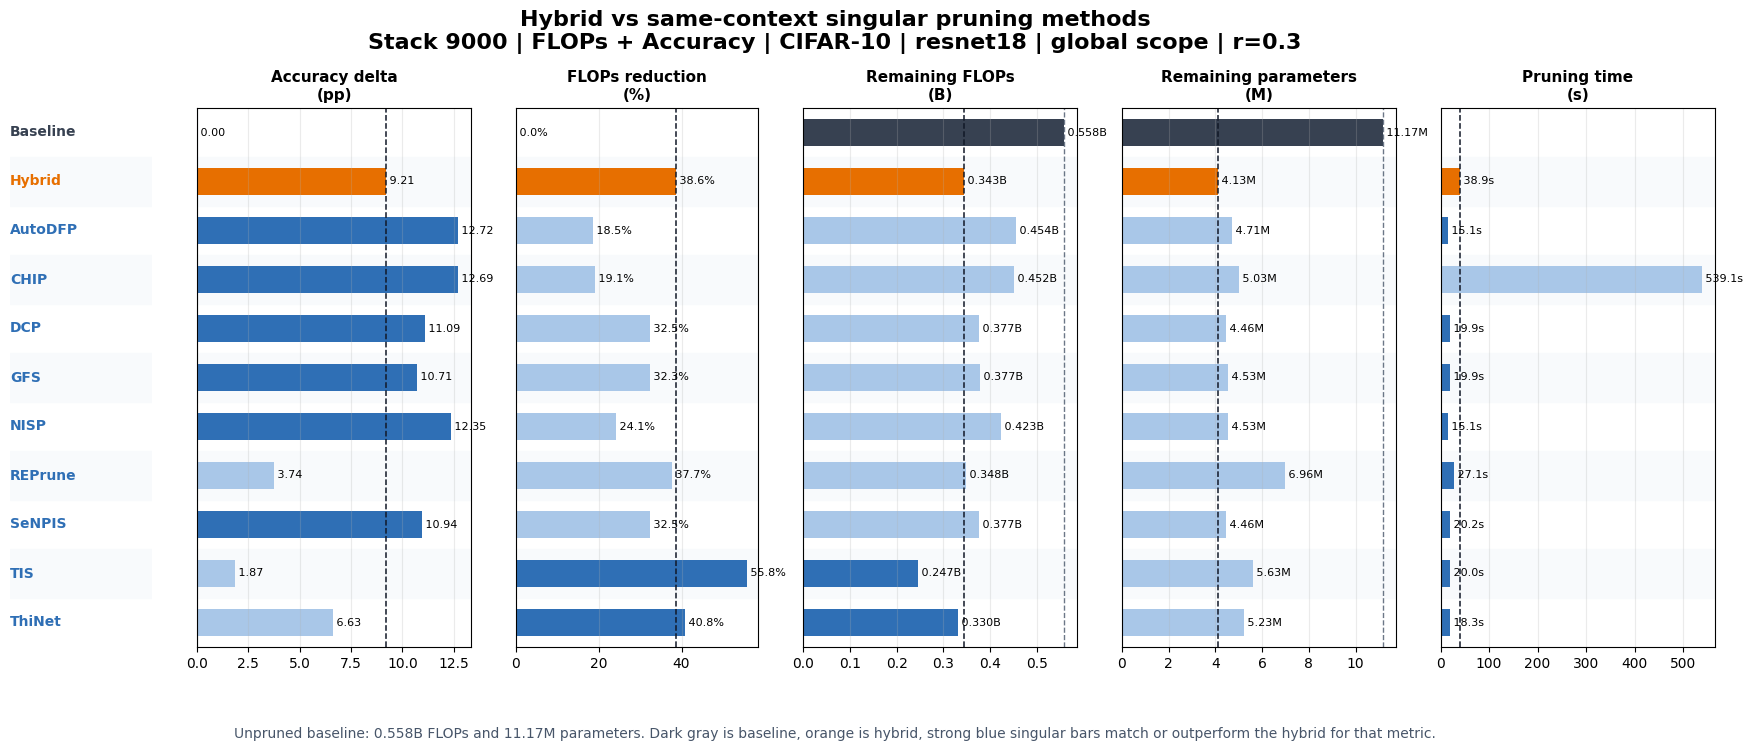


=== Context: cifar10 | resnet18 | flops_accuracy | global | r=0.45 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_flops_accuracy_global_r0.45_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/global/r0.45/heal3_healb30

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


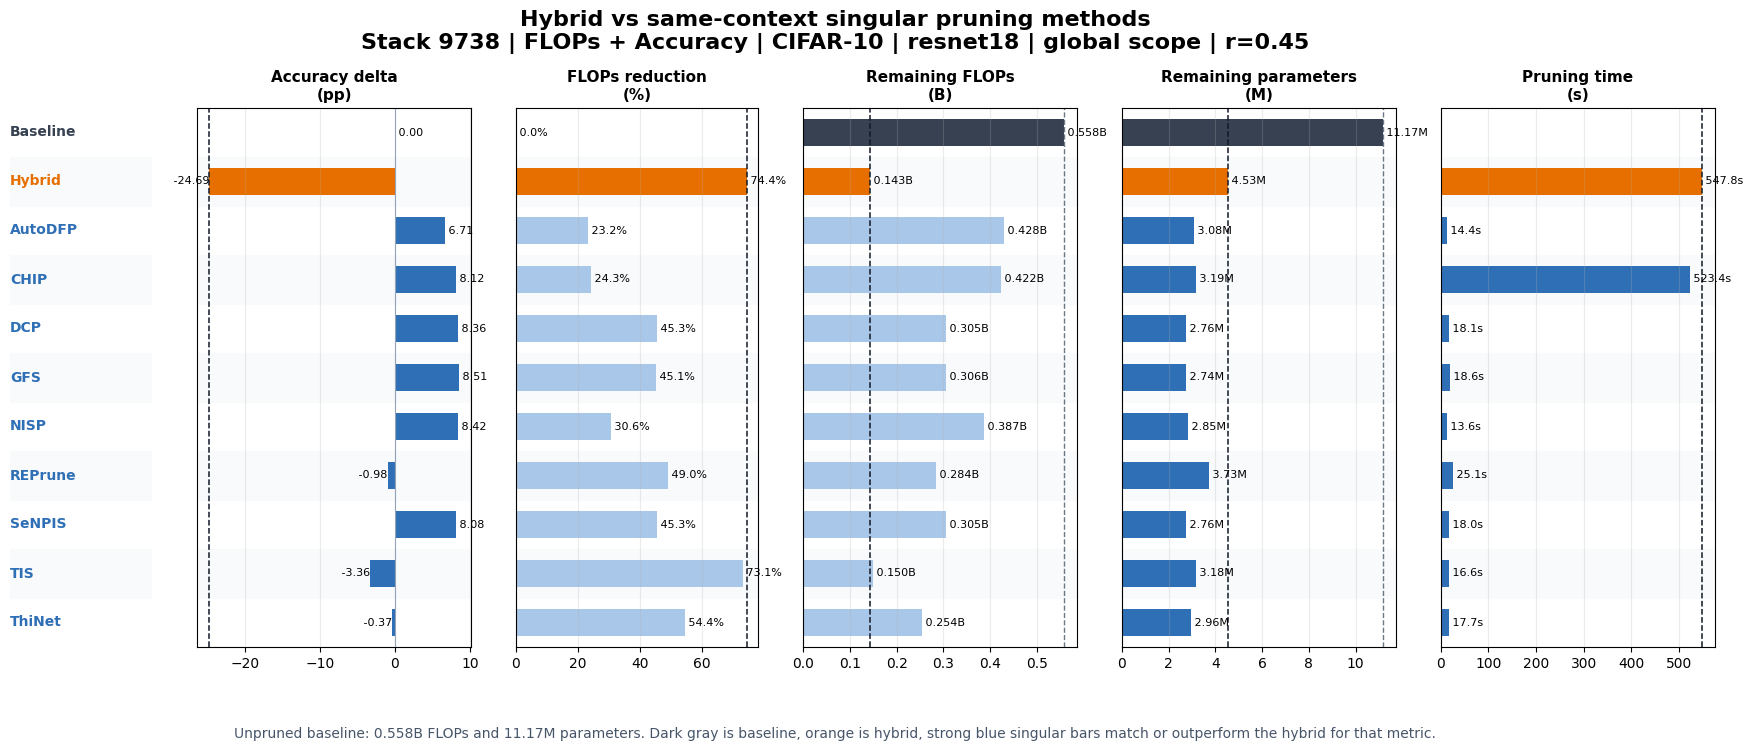


=== Context: cifar10 | resnet18 | flops_accuracy | global | r=0.55 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_flops_accuracy_global_r0.55_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/global/r0.55/heal3_healb30

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


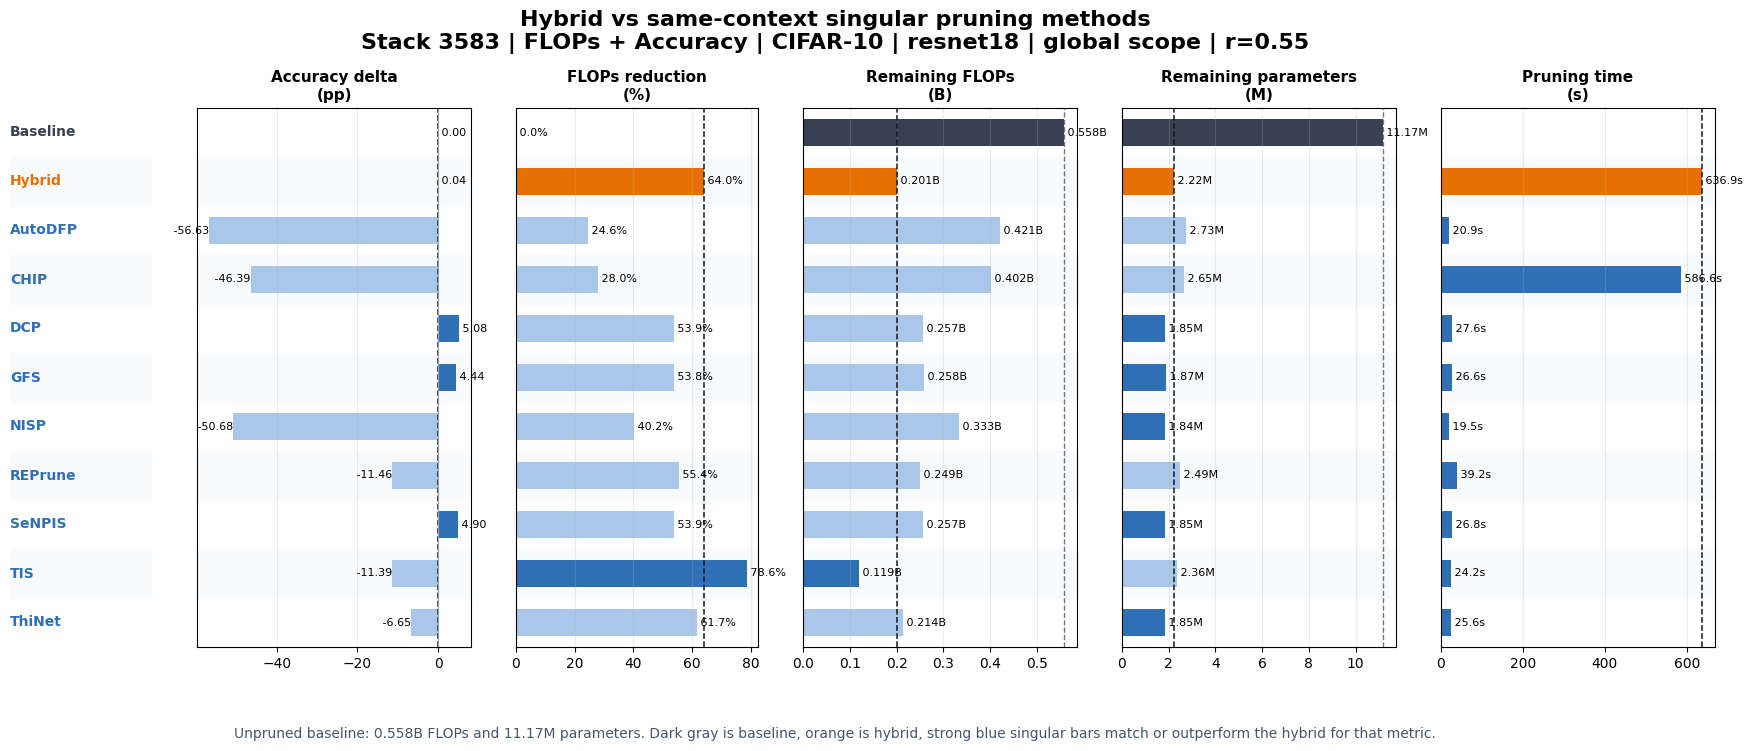


=== Context: cifar10 | vgg16 | flops_accuracy | global | r=0.3 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_flops_accuracy_global_r0.3_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/global/r0.3/heal3_healb30_healval16_score8_

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


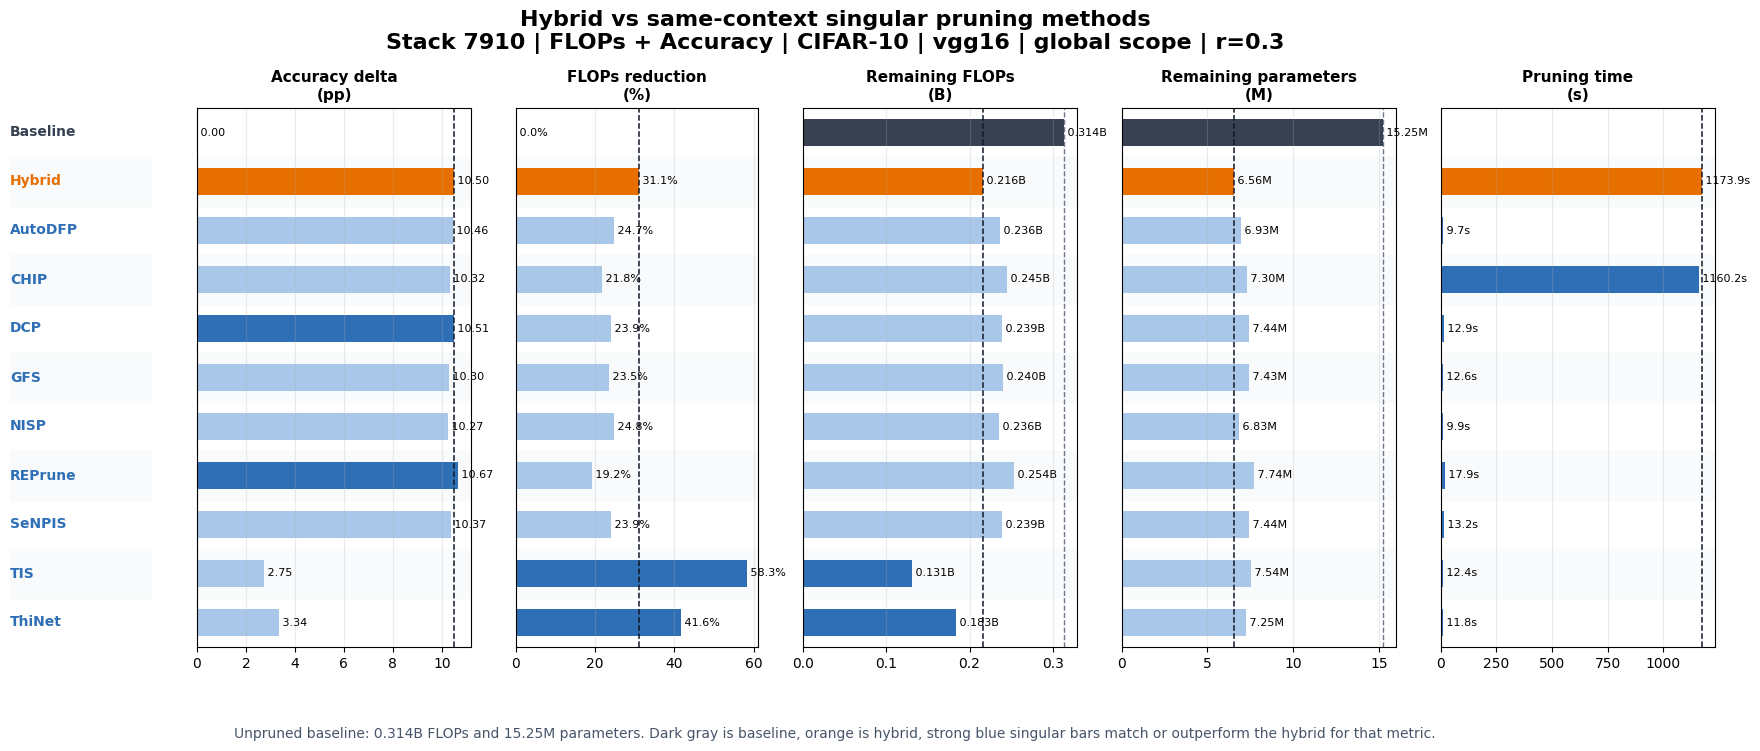


=== Context: cifar10 | vgg16 | flops_accuracy | global | r=0.45 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_flops_accuracy_global_r0.45_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/global/r0.45/heal3_healb30_healval16_scor

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


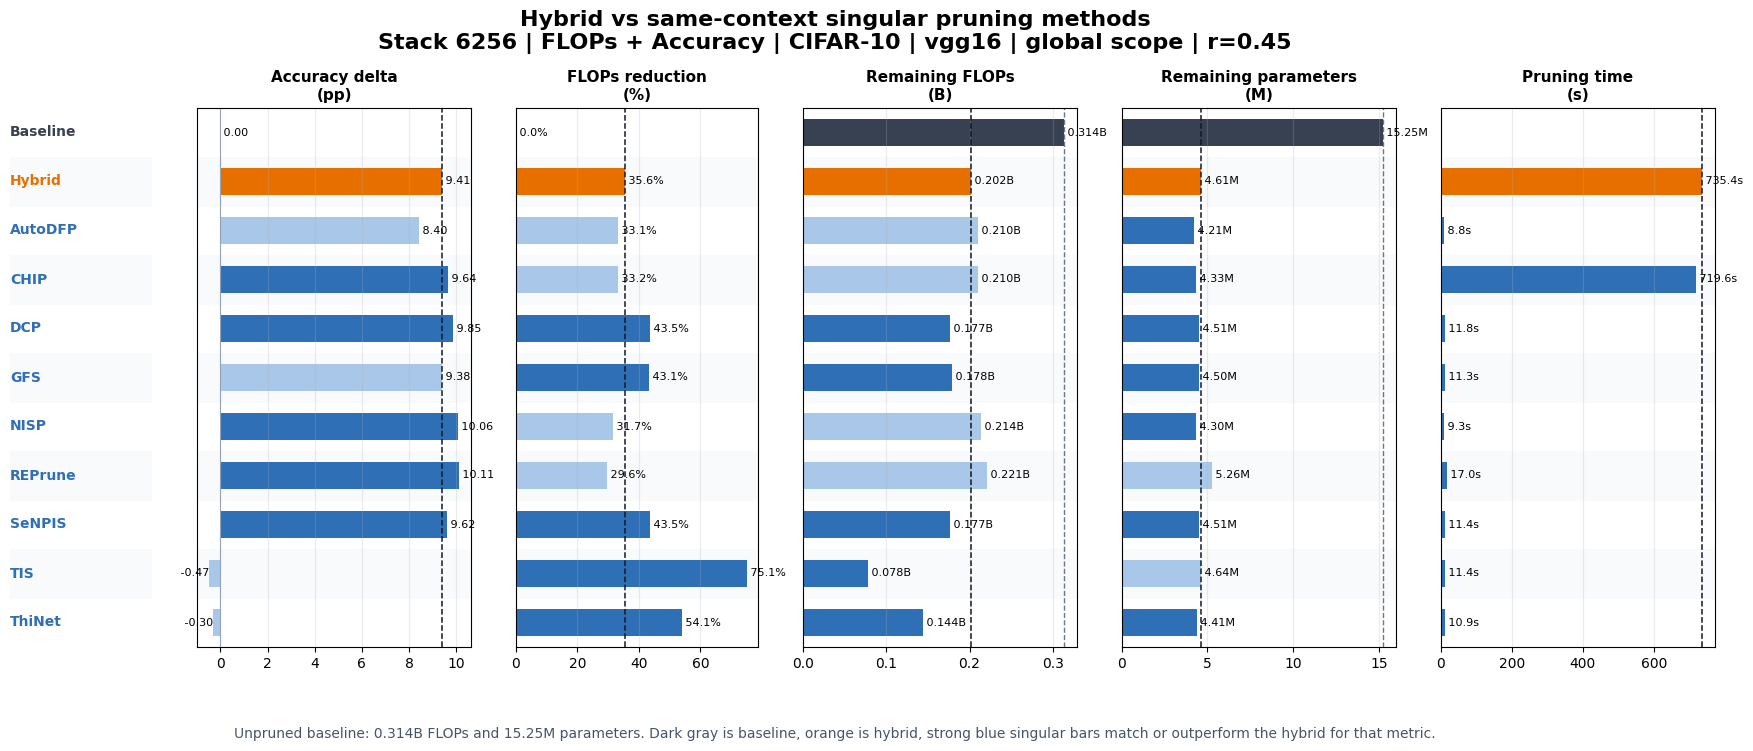


=== Context: cifar10 | vgg16 | flops_accuracy | global | r=0.55 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_flops_accuracy_global_r0.55_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/global/r0.55/heal3_healb30_healval16_scor

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


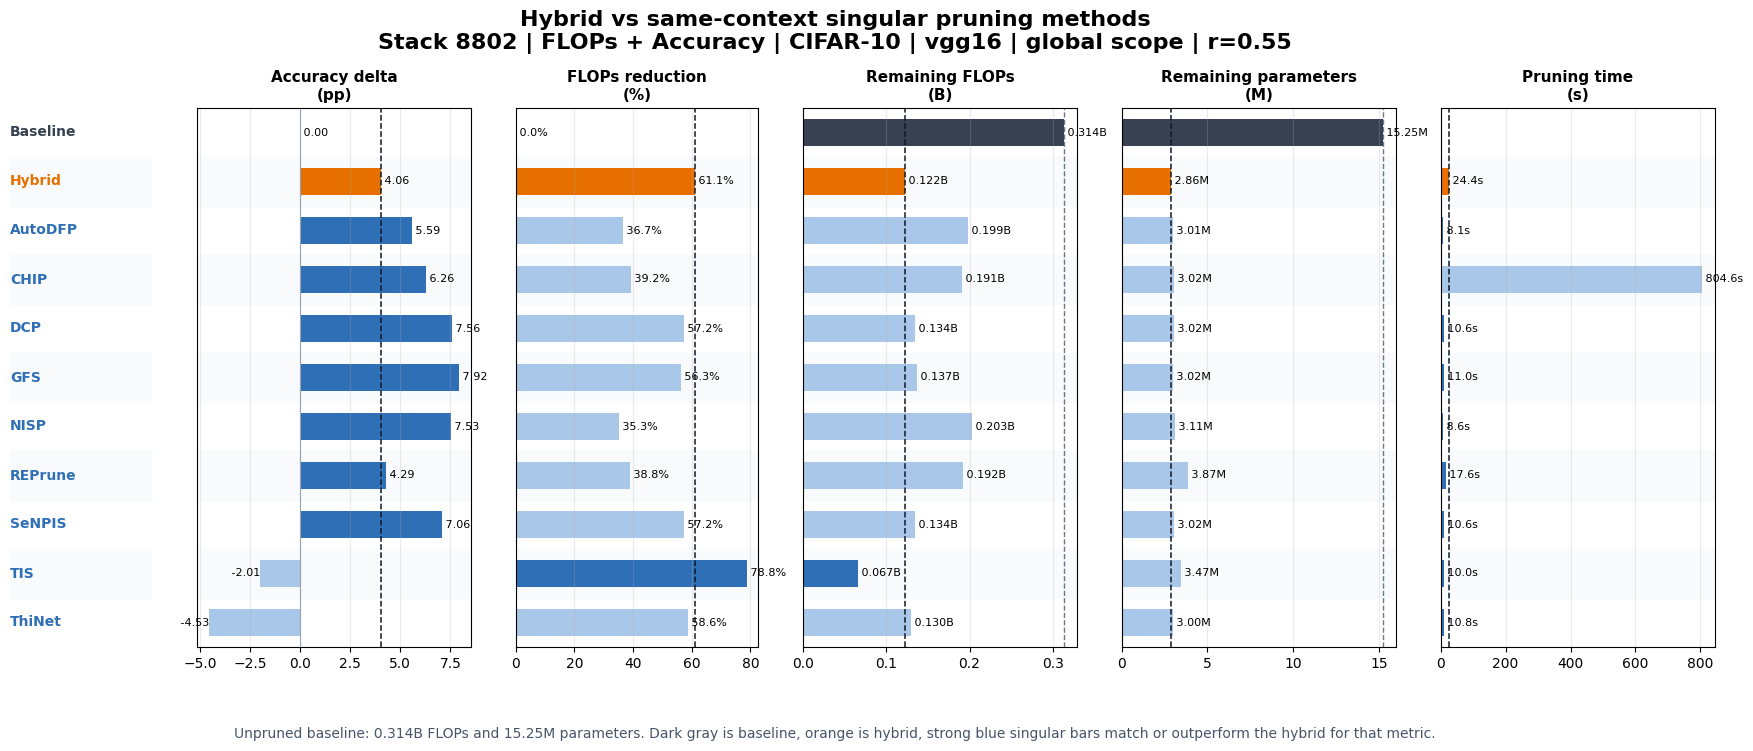


=== Context: cifar10 | resnet18 | time_accuracy | local | r=0.55 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_time_accuracy_local_r0.55_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/local/r0.55/heal3

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


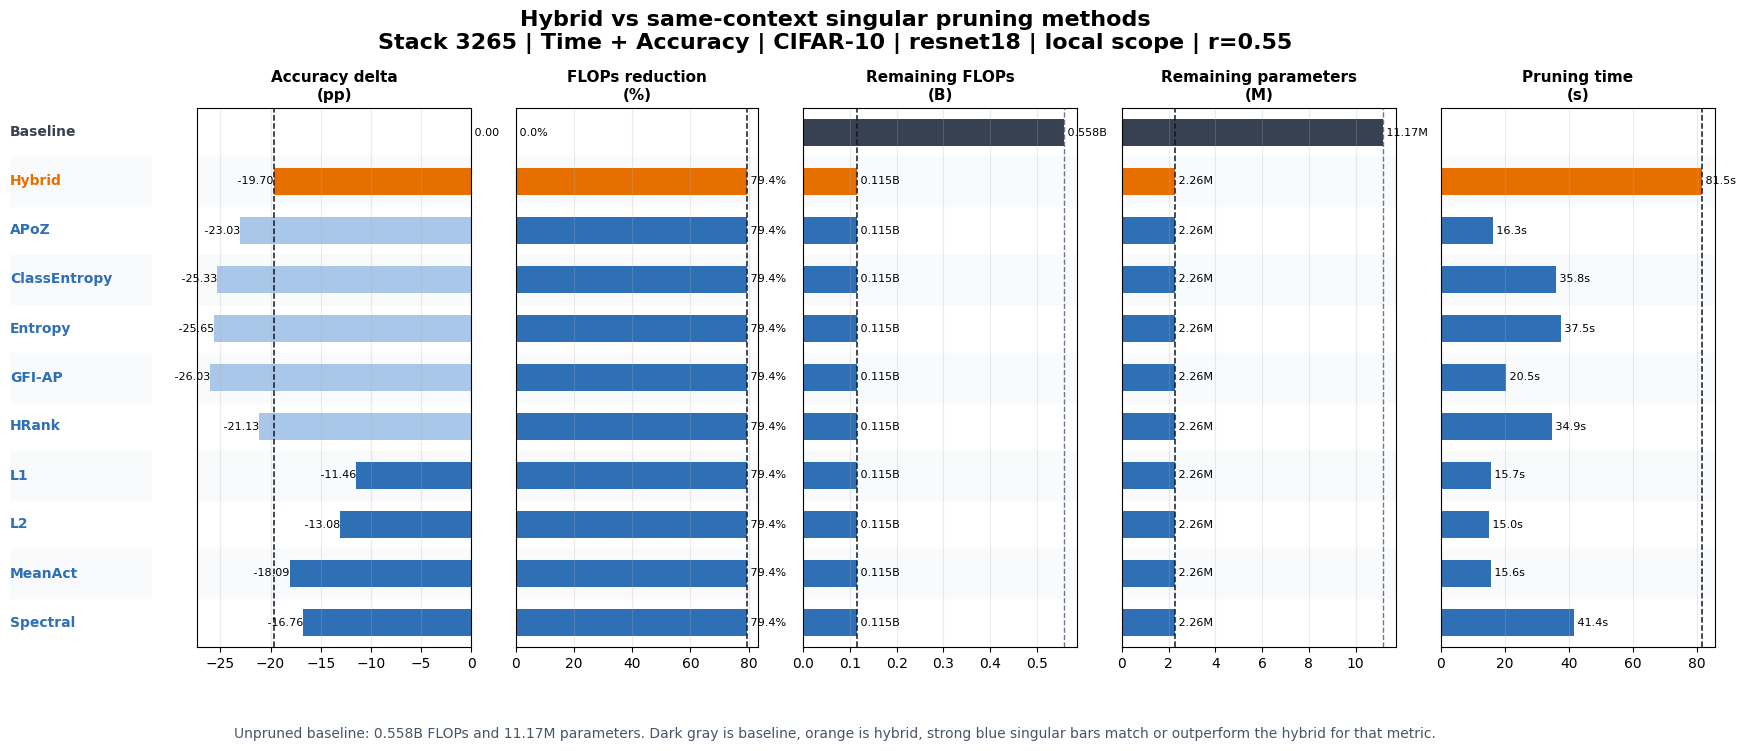

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


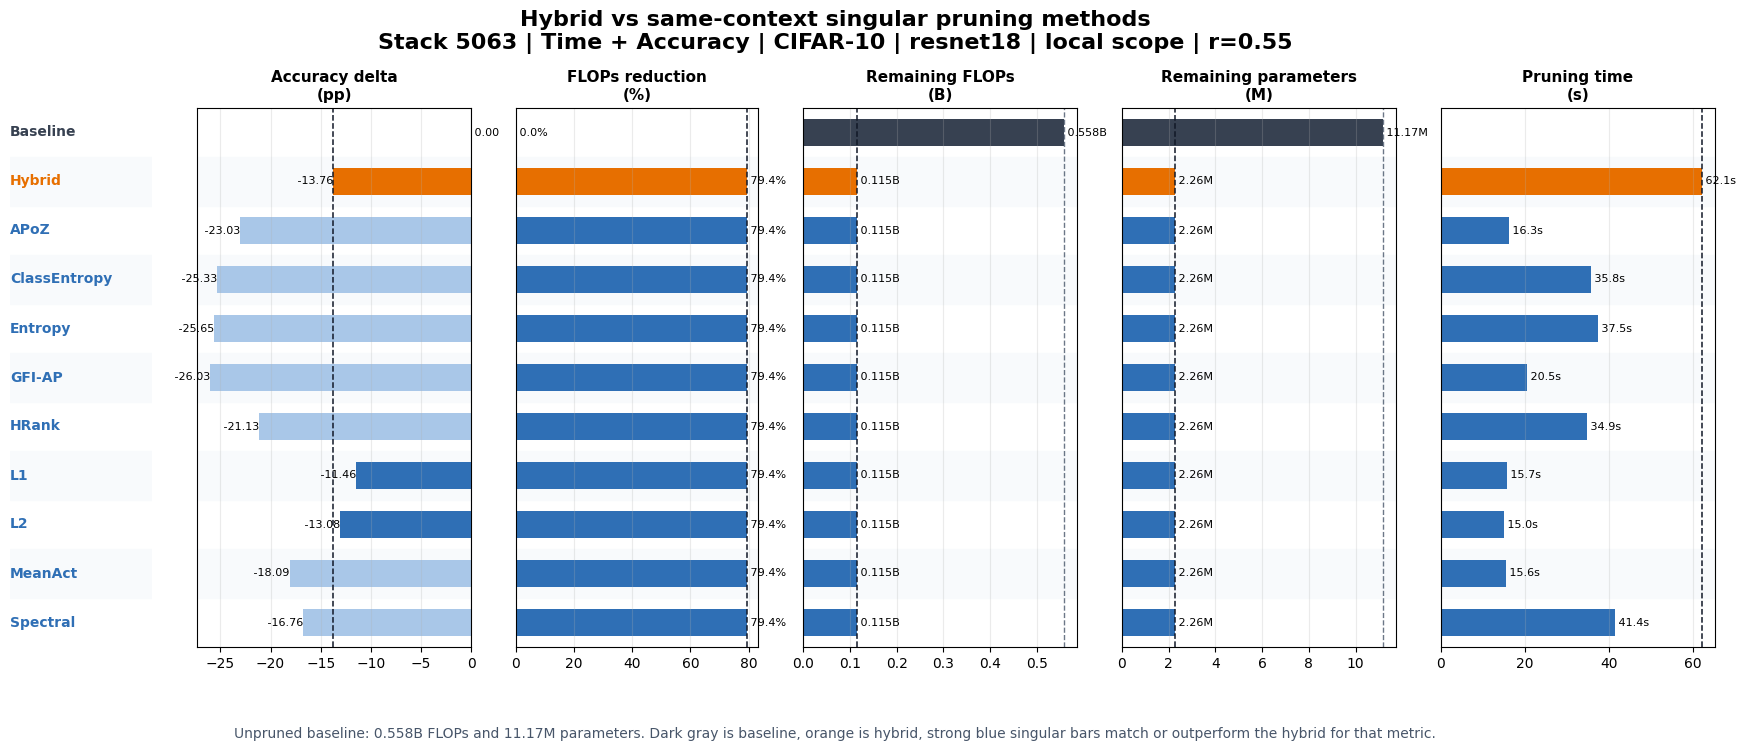


=== Context: cifar10 | resnet18 | flops_accuracy | local | r=0.55 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_flops_accuracy_local_r0.55_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/local/r0.55/hea

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


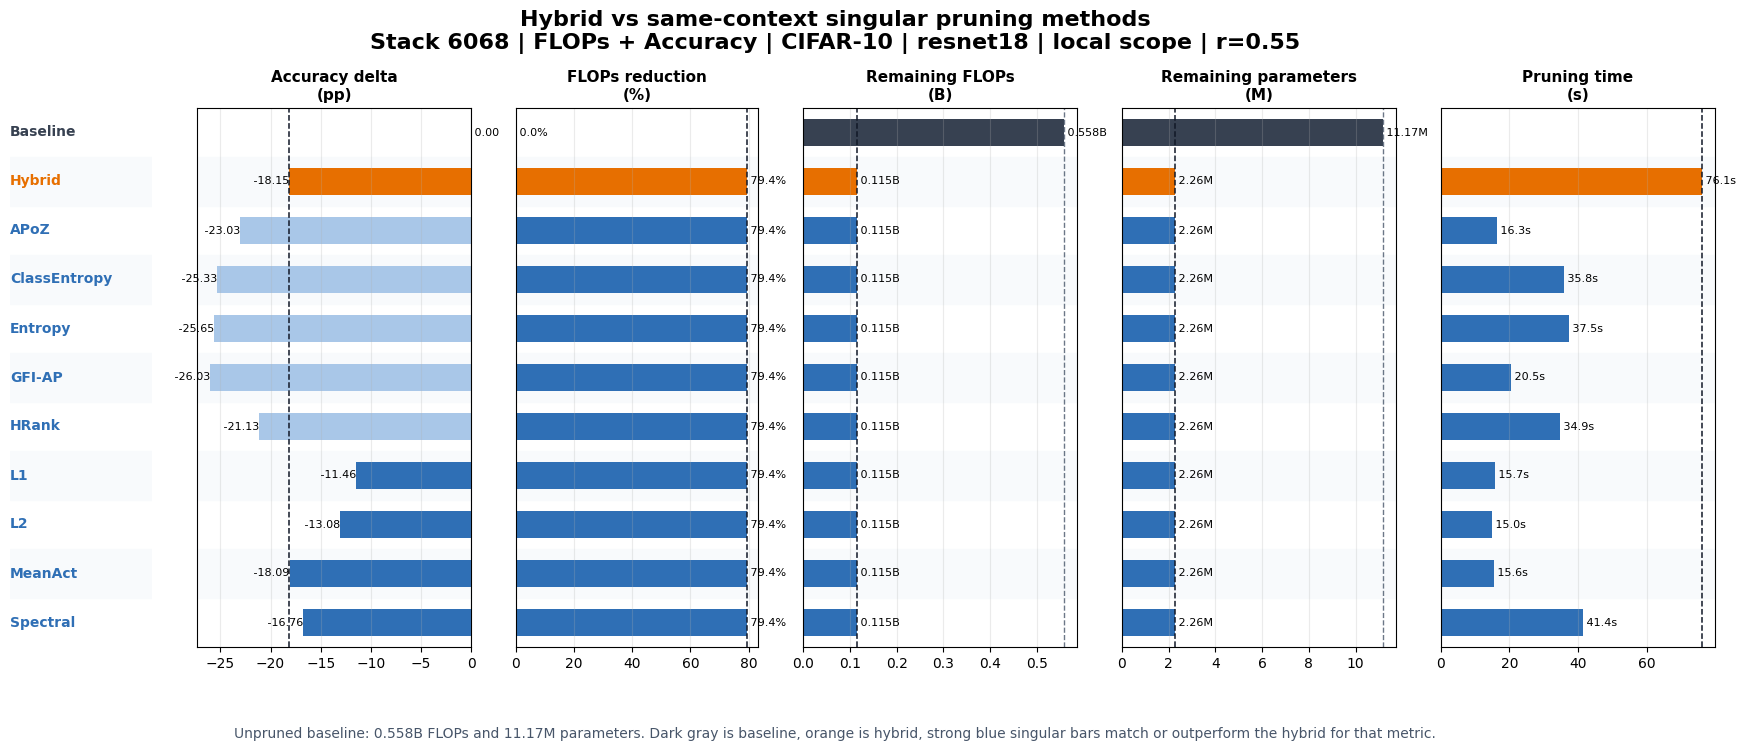


=== Context: cifar10 | vgg16 | time_accuracy | local | r=0.3 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_time_accuracy_local_r0.3_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/local/r0.3/heal3_healb30_healval16

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


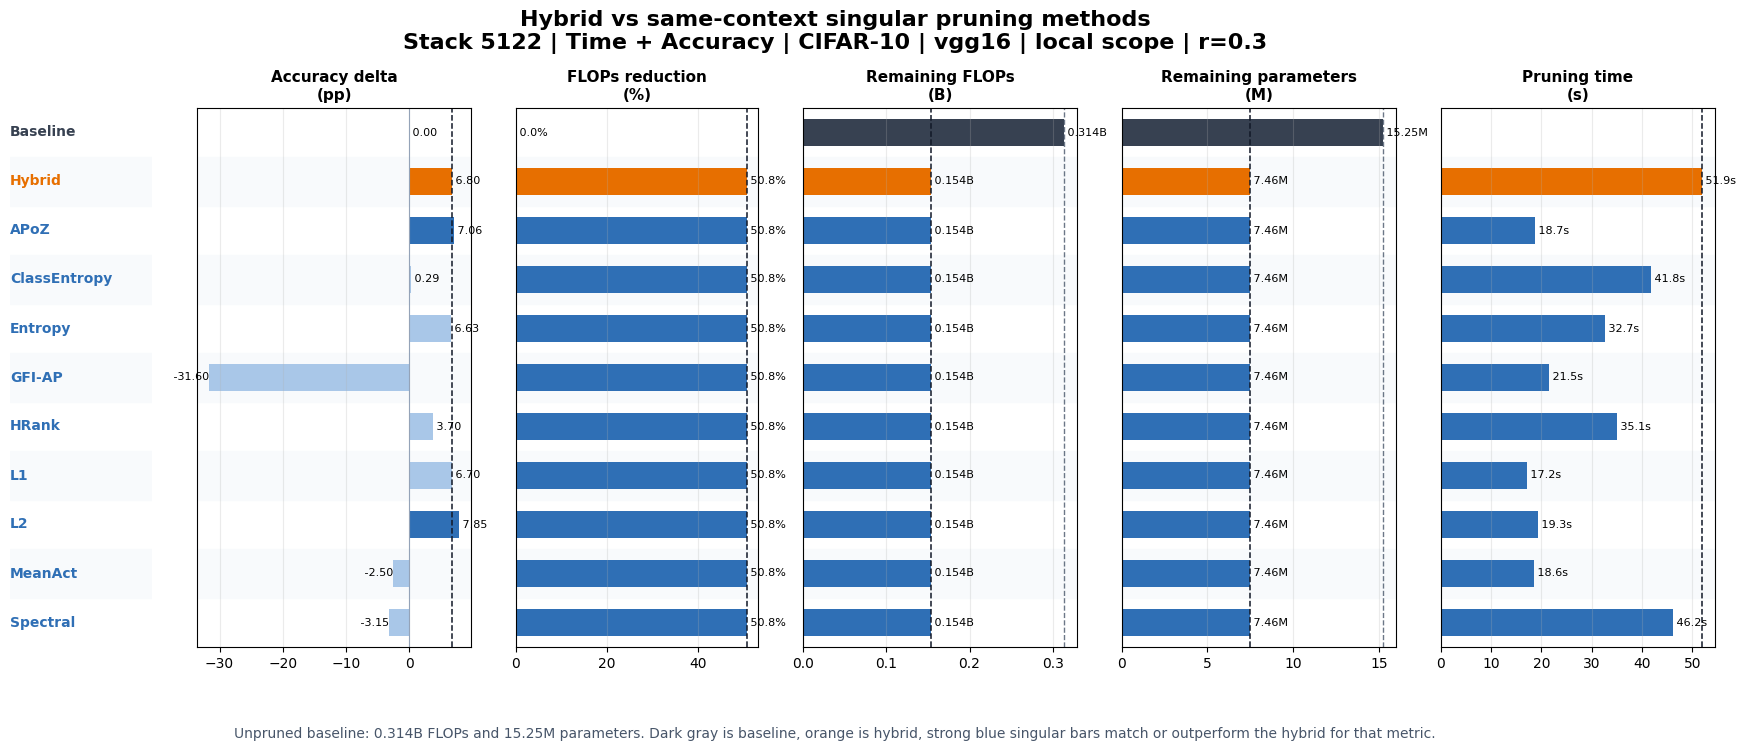

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


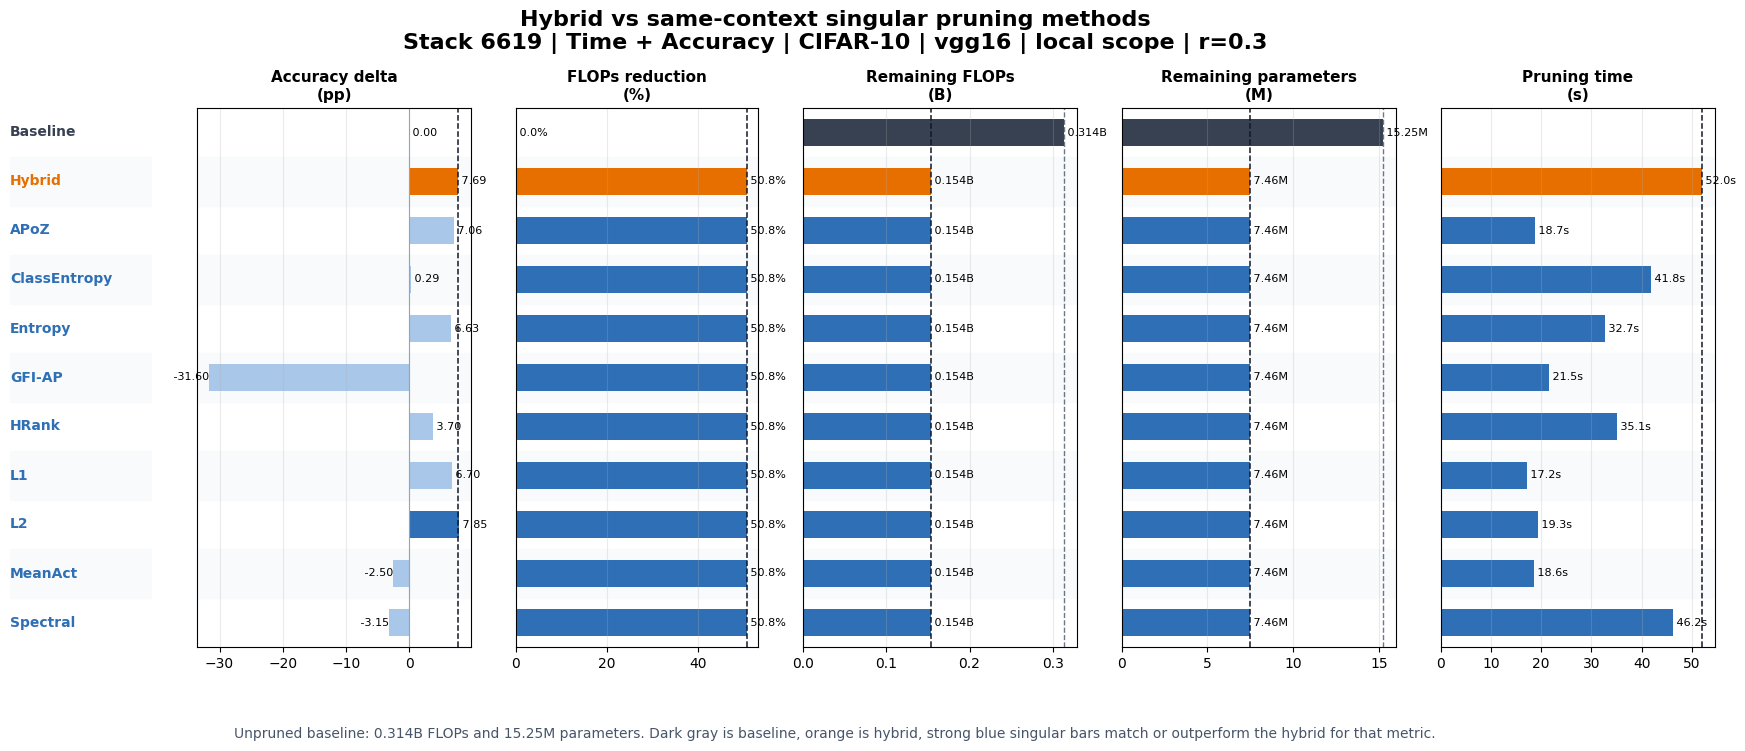


=== Context: cifar10 | vgg16 | flops_accuracy | local | r=0.3 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_flops_accuracy_local_r0.3_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/local/r0.3/heal3_healb30_healval

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


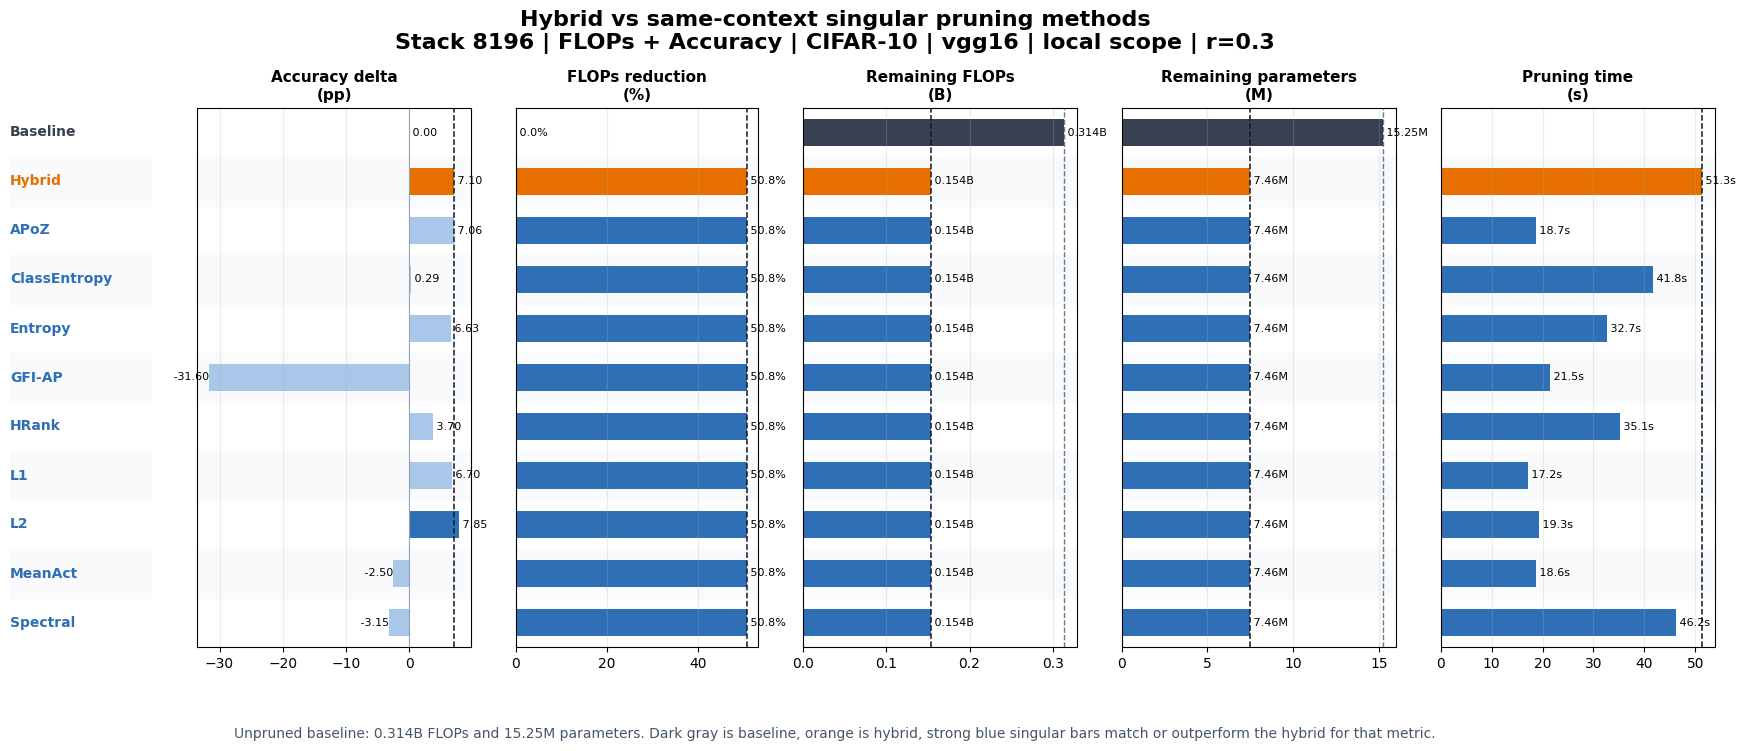


=== Context: cifar10 | vgg16 | time_accuracy | global | r=0.55 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_time_accuracy_global_r0.55_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/global/r0.55/heal3_healb30_healval16_score8

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


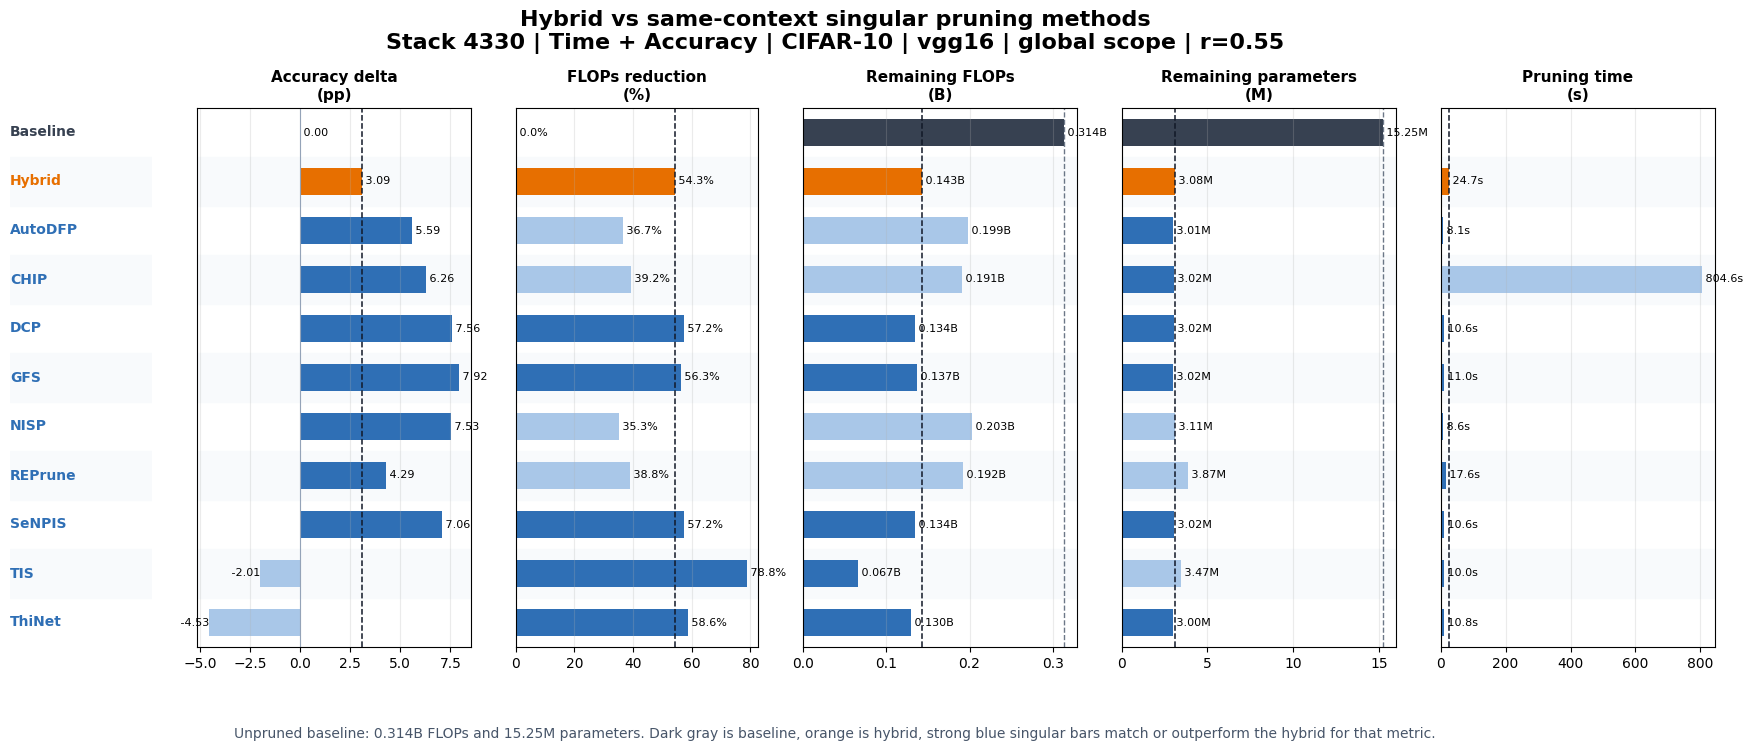


=== Context: cifar10 | vgg16 | time_accuracy | global | r=0.45 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 64, 'scoring_batches': 8, 'heavy_batches': 4, 'chip_max_spatial': 16, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.90% / 77.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/vgg16/pytorch_vgg16_cifar-10.pth
Cache hit: singular_cifar10_vgg16_time_accuracy_global_r0.45_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/vgg16/all_objectives/global/r0.45/heal3_healb30_healval16_score8

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


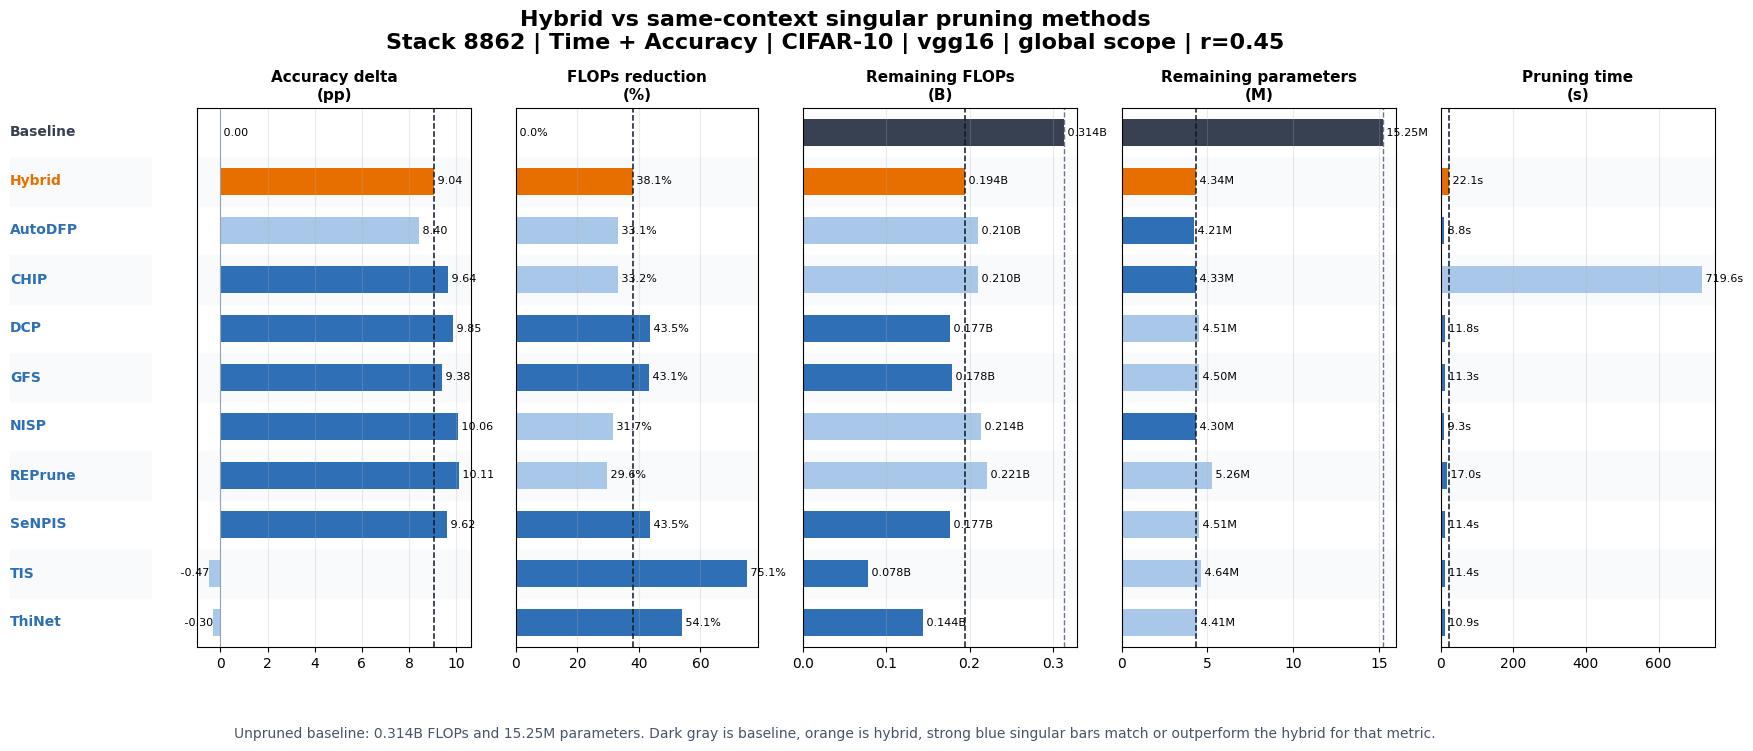


=== Context: cifar10 | resnet18 | time_accuracy | global | r=0.45 ===
Same-scope singular benchmark methods: ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Runtime settings: {'batch_size': 128, 'scoring_batches': 4, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 16}
Baseline validation/test accuracy: 84.64% / 76.40% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Cache hit: singular_cifar10_resnet18_time_accuracy_global_r0.45_chip -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cifar10/resnet18/all_objectives/global/r0.45/heal3_healb30_h

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


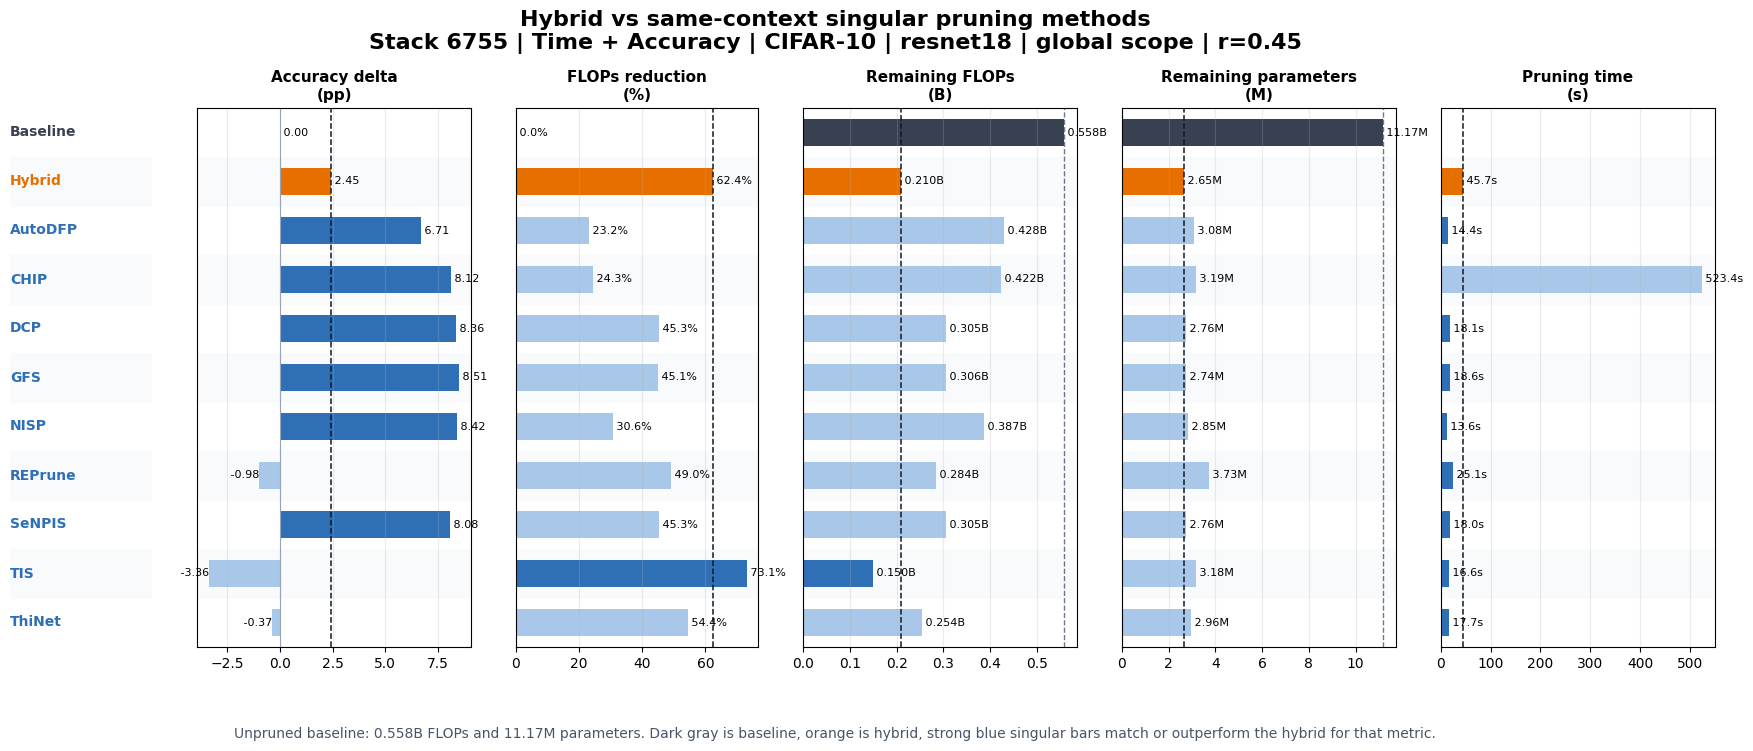


=== Context: cats_dogs | resnet18 | time_accuracy | local | r=0.3 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 64, 'scoring_batches': 3, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 8}
Baseline validation/test accuracy: 97.16% / 97.55% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cats_dogs/resnet18/20260505_165317_pytorch_resnet18_cats_dogs_catdog_workflow_1epoch.pth
Cache hit: singular_cats_dogs_resnet18_time_accuracy_local_r0.3_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cats_dog

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


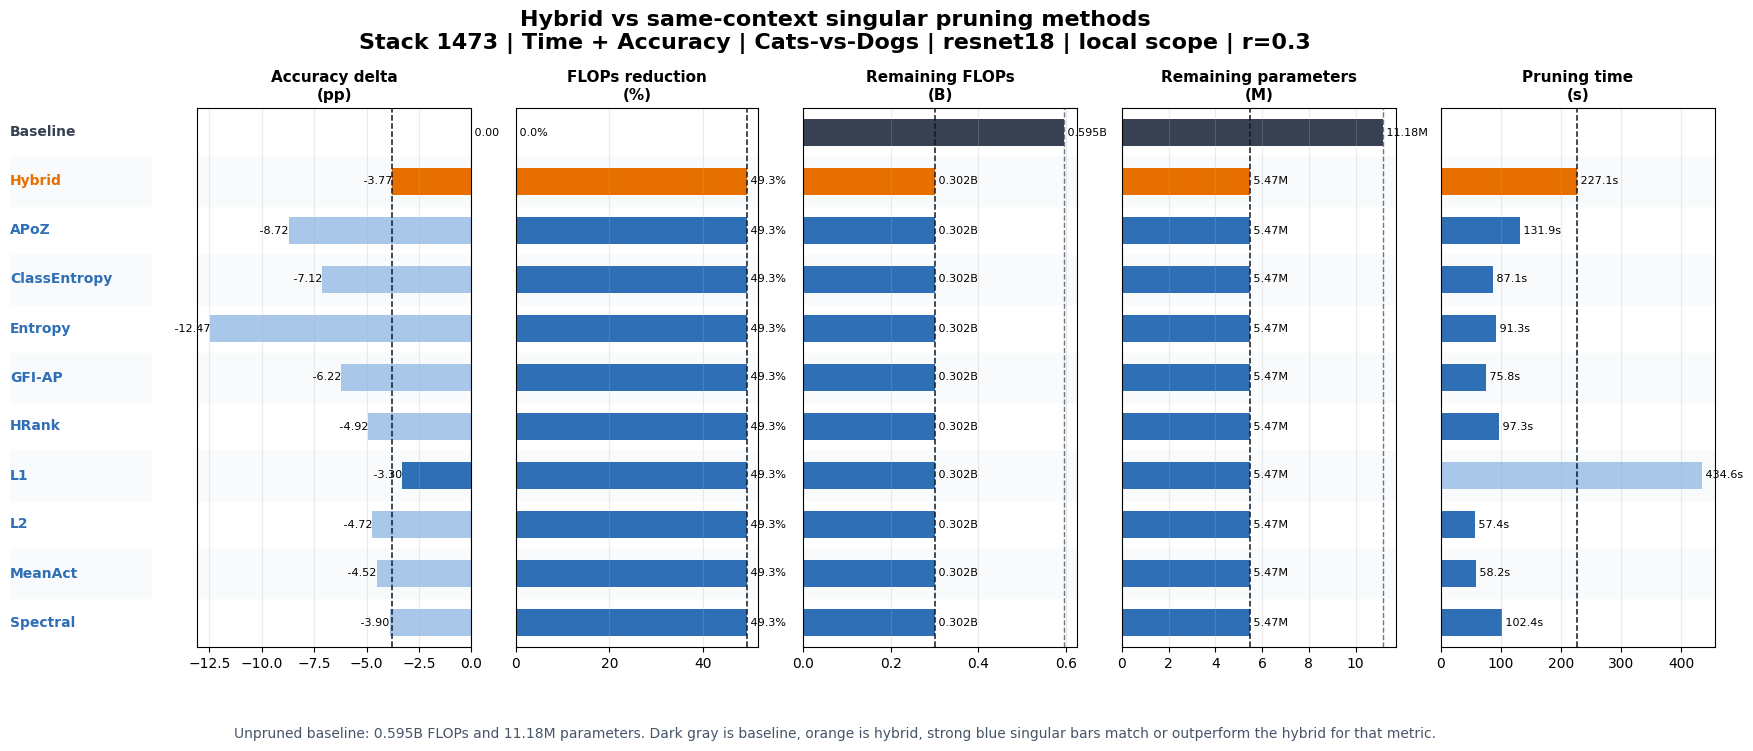


=== Context: cats_dogs | vgg16 | time_accuracy | local | r=0.3 ===
Same-scope singular benchmark methods: ['L1', 'L2', 'MeanAct', 'APoZ', 'Entropy', 'GFI-AP', 'ClassEntropy', 'HRank', 'Spectral']
Runtime settings: {'batch_size': 32, 'scoring_batches': 3, 'heavy_batches': 2, 'chip_max_spatial': 8, 'baseline_eval_max_batches': None, 'benchmark_eval_max_batches': None, 'healing_epochs': 3, 'healing_train_batches': 30, 'healing_val_batches': 8}
Baseline validation/test accuracy: 97.80% / 98.47% from /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cats_dogs/vgg16/20260504_091425_pytorch_vgg16_cats_dogs_catdog_workflow_1epoch.pth
Cache hit: singular_cats_dogs_vgg16_time_accuracy_local_r0.3_l1_norm -> /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/artifact_cache/3_catdog_shuffled_split_baseline_gate/singular/cats_dogs/vgg16/all_

/tmp/ipykernel_34606/1869701917.py:505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


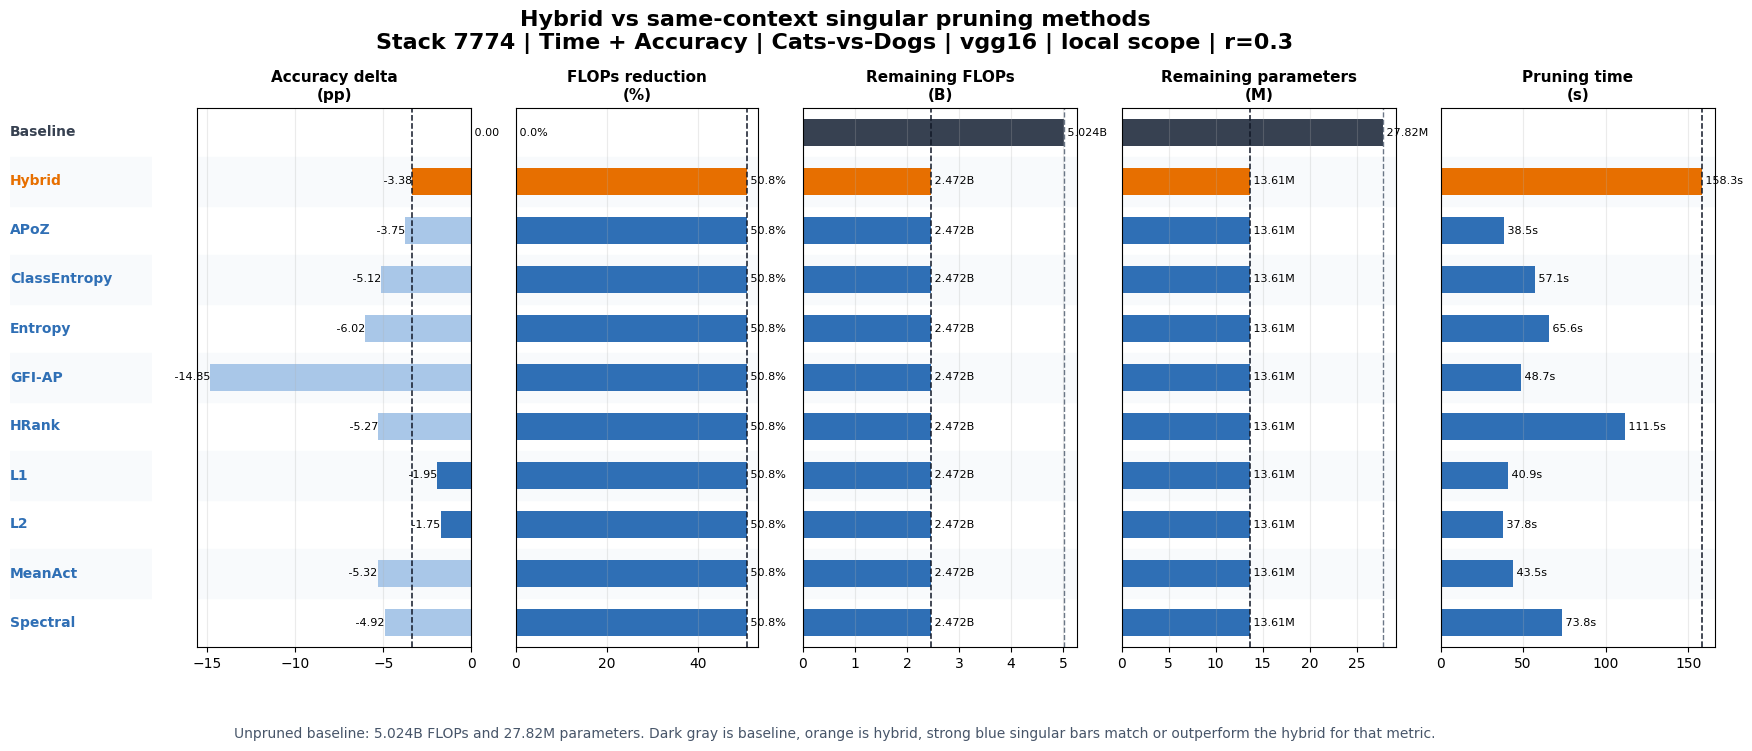

,method_type,method,method_display,stack_id,dataset,dataset_label,model,objective,objective_label,scope,...,mask_build_time_sec,structural_surgery_time_sec,healing_time_sec,selected_method_scoring_time_sec,mask_audit,checkpoint_path,cache_metadata_path,cache_hit,context_rank,layer_policy
0,baseline,baseline,Baseline,,cifar10,CIFAR-10,resnet18,flops_accuracy,FLOPs + Accuracy,global,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,singular,chip,CHIP,,cifar10,CIFAR-10,resnet18,flops_accuracy,FLOPs + Accuracy,global,...,0.001443,0.174332,14.674462,524.260333,"{'total_filters': 4800, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
2,singular,custom_reprune,REPrune,,cifar10,CIFAR-10,resnet18,flops_accuracy,FLOPs + Accuracy,global,...,0.001050,0.065971,14.658035,12.405858,"{'total_filters': 4800, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
3,singular,custom_nisp,NISP,,cifar10,CIFAR-10,resnet18,flops_accuracy,FLOPs + Accuracy,global,...,0.001205,0.061959,14.831004,0.245947,"{'total_filters': 4800, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
4,singular,custom_senpis,SeNPIS,,cifar10,CIFAR-10,resnet18,flops_accuracy,FLOPs + Accuracy,global,...,0.001081,0.061086,14.697364,5.485731,"{'total_filters': 4800, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,singular,custom_gfi_ap,GFI-AP,,cats_dogs,Cats-vs-Dogs,vgg16,time_accuracy,Time + Accuracy,local,...,0.000648,0.052493,39.210896,9.438184,"{'total_filters': 5248, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
163,singular,custom_class_entropy,ClassEntropy,,cats_dogs,Cats-vs-Dogs,vgg16,time_accuracy,Time + Accuracy,local,...,0.001194,0.716631,39.531256,16.858544,"{'total_filters': 5248, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
164,singular,custom_hrank,HRank,,cats_dogs,Cats-vs-Dogs,vgg16,time_accuracy,Time + Accuracy,local,...,0.000937,0.046943,38.022038,73.436701,"{'total_filters': 5248, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN
165,singular,custom_spectral_energy,Spectral,,cats_dogs,Cats-vs-Dogs,vgg16,time_accuracy,Time + Accuracy,local,...,0.000684,0.053112,38.542226,35.194593,"{'total_filters': 5248, 'total_pruned_filters'...",/content/drive/.shortcut-targets-by-id/14yEksj...,/content/drive/.shortcut-targets-by-id/14yEksj...,True,NaN,NaN


,stack_id,dataset,model,objective,scope,ratio,plot
0,9000,cifar10,resnet18,flops_accuracy,global,0.30,/content/drive/.shortcut-targets-by-id/14yEksj...
1,9738,cifar10,resnet18,flops_accuracy,global,0.45,/content/drive/.shortcut-targets-by-id/14yEksj...
2,3583,cifar10,resnet18,flops_accuracy,global,0.55,/content/drive/.shortcut-targets-by-id/14yEksj...
3,7910,cifar10,vgg16,flops_accuracy,global,0.30,/content/drive/.shortcut-targets-by-id/14yEksj...
4,6256,cifar10,vgg16,flops_accuracy,global,0.45,/content/drive/.shortcut-targets-by-id/14yEksj...
5,8802,cifar10,vgg16,flops_accuracy,global,0.55,/content/drive/.shortcut-targets-by-id/14yEksj...
6,3265,cifar10,resnet18,time_accuracy,local,0.55,/content/drive/.shortcut-targets-by-id/14yEksj...
7,5063,cifar10,resnet18,time_accuracy,local,0.55,/content/drive/.shortcut-targets-by-id/14yEksj...
8,6068,cifar10,resnet18,flops_accuracy,local,0.55,/content/drive/.shortcut-targets-by-id/14yEksj...
9,5122,cifar10,vgg16,time_accuracy,local,0.30,/content/drive/.shortcut-targets-by-id/14yEksj...


In [31]:
all_metrics = []
plot_rows = []

if REPRODUCTION_DRY_RUN:
    print("Dry run stops before data/model loading. Timelines and manifest validation completed.")
else:
    contexts = {}
    for stack in stacks:
        key = (stack["dataset"], stack["model"], stack["objective"], stack["scope"], float(stack["ratio"]))
        contexts.setdefault(key, []).append(stack)

    for (dataset, model, objective, scope, ratio), context_stacks in contexts.items():
        cfg = effective_context_config(DATASET_CONFIG[(dataset, model)])
        print(f"\n=== Context: {dataset} | {model} | {objective} | {scope} | r={ratio:g} ===")
        allowed_context_methods = set(same_scope_methods(scope))
        for stack in context_stacks:
            assert_policy_respects_scope(
                stack["policy"],
                scope,
                f"hybrid stack {stack['stack_id']} ({dataset}/{model}/{objective}/{scope}/r={ratio:g})",
            )
        print("Same-scope singular benchmark methods:", [METHOD_LABELS.get(m, m) for m in same_scope_methods(scope)])
        print(
            "Runtime settings:",
            {
                "batch_size": cfg["batch_size"],
                "scoring_batches": cfg["scoring_batches"],
                "heavy_batches": cfg["heavy_batches"],
                "chip_max_spatial": cfg["chip_max_spatial"],
                "baseline_eval_max_batches": BASELINE_EVAL_MAX_BATCHES,
                "benchmark_eval_max_batches": BENCHMARK_EVAL_MAX_BATCHES,
                "healing_epochs": HEALING_EPOCHS,
                "healing_train_batches": HEALING_TRAIN_BATCHES,
                "healing_val_batches": cfg["healing_val_batches"],
            },
        )
        loaders = make_loaders(dataset, cfg)
        adapter_cfg = {
            "backend": "pytorch", "dataset": cfg["dataset_label"], "model_type": model,
            "input_shape": cfg["input_shape"], "num_classes": cfg["num_classes"],
            "prune_batches": cfg["scoring_batches"], "calib_batches": cfg["scoring_batches"],
            "calibration_batches": cfg["scoring_batches"], "prune_batches_default": cfg["scoring_batches"],
            "chip_max_spatial": cfg["chip_max_spatial"], "lr": 1e-4, "torch_restore_best": True,
            "baseline_checkpoint_policy": "off",
        }
        adapter = get_adapter(None, adapter_cfg)
        baseline_model, baseline_val, baseline_test = load_or_train_baseline(adapter, dataset, model, cfg, loaders)
        baseline_flops, baseline_params = profile(adapter, baseline_model, loaders["test"])
        baseline_row = {
            "method_type": "baseline", "method": "baseline", "method_display": "Baseline", "stack_id": "",
            "dataset": dataset, "dataset_label": context_stacks[0]["dataset_label"], "model": model,
            "objective": objective, "objective_label": context_stacks[0]["objective_label"],
            "scope": scope, "ratio": ratio, "baseline_validation_accuracy_pct": baseline_val,
            "baseline_test_accuracy_pct": baseline_test, "baseline_flops": baseline_flops,
            "baseline_params": baseline_params, "final_test_accuracy_pct": baseline_test,
            "accuracy_delta_pp": 0.0, "final_flops": baseline_flops, "final_params": baseline_params,
            "flops_reduction_pct": 0.0, "params_reduction_pct": 0.0,
            "remaining_flops_b": baseline_flops / 1e9, "remaining_params_m": baseline_params / 1e6,
            "deployment_pruning_time_sec": np.nan,
            "scoring_calib_batches": cfg["scoring_batches"], "heavy_method_batches": cfg["heavy_batches"],
            "chip_max_spatial": cfg["chip_max_spatial"], "healing_val_batches": cfg["healing_val_batches"],
        }
        context_metrics = [baseline_row]

        score_maps = {}
        score_time_by_method = {}
        required_methods = set()
        pending_singular = []
        pending_hybrid = []

        # Singular baselines in the exact same context.
        if RUN_SINGULAR_BENCHMARKS:
            for method in same_scope_methods(scope):
                if method not in allowed_context_methods:
                    raise RuntimeError(f"Internal scope bug: method {method} is not valid for {scope}")
                singular_policy = [(layer, method) for layer, _m in context_stacks[0]["policy"]]
                artifact_id = f"singular_{dataset}_{model}_{objective}_{scope}_r{ratio:g}_{method}"
                row_meta = {
                    "artifact_id": artifact_id, "method_type": "singular", "method": method,
                    "method_display": METHOD_LABELS.get(method, method), "stack_id": "",
                    "dataset": dataset, "dataset_label": context_stacks[0]["dataset_label"],
                    "model": model, "objective": objective, "objective_label": context_stacks[0]["objective_label"],
                    "scope": scope, "ratio": ratio, "baseline_validation_accuracy_pct": baseline_val,
                    "baseline_test_accuracy_pct": baseline_test, "baseline_flops": baseline_flops,
                    "baseline_params": baseline_params, "score_time_by_method": score_time_by_method,
                    "scoring_calib_batches": cfg["scoring_batches"], "heavy_method_batches": cfg["heavy_batches"],
                    "chip_max_spatial": cfg["chip_max_spatial"], "healing_val_batches": cfg["healing_val_batches"],
                }
                cached = load_cached_artifact(row_meta)
                if cached is not None:
                    context_metrics.append(cached)
                else:
                    pending_singular.append((method, singular_policy, row_meta))
                    required_methods.add(method)

        # Frozen hybrid stacks in the same context.
        for stack in context_stacks:
            artifact_id = f"hybrid_stack_{stack['stack_id']}_{dataset}_{model}_{objective}_{scope}_r{ratio:g}"
            row_meta = {
                "artifact_id": artifact_id, "method_type": "hybrid", "method": "hybrid_stack",
                "method_display": "Hybrid", "stack_id": str(stack["stack_id"]),
                "dataset": dataset, "dataset_label": stack["dataset_label"], "model": model,
                "objective": objective, "objective_label": stack["objective_label"], "scope": scope,
                "ratio": ratio, "context_rank": stack.get("context_rank"),
                "baseline_validation_accuracy_pct": baseline_val, "baseline_test_accuracy_pct": baseline_test,
                "baseline_flops": baseline_flops, "baseline_params": baseline_params,
                "score_time_by_method": score_time_by_method,
                "scoring_calib_batches": cfg["scoring_batches"], "heavy_method_batches": cfg["heavy_batches"],
                "chip_max_spatial": cfg["chip_max_spatial"], "healing_val_batches": cfg["healing_val_batches"],
            }
            cached = load_cached_artifact(row_meta)
            if cached is not None:
                context_metrics.append(cached)
            else:
                pending_hybrid.append((stack, row_meta))
                required_methods.update(method for _layer, method in stack["policy"])

        if required_methods:
            score_maps, score_timing = score_methods(adapter, baseline_model, loaders["calib"], required_methods, cfg)
            score_timing["dataset"] = dataset
            score_timing["model"] = model
            score_timing["objective"] = objective
            score_timing["scope"] = scope
            score_timing["ratio"] = ratio
            score_timing_path = RUN_DIR / f"method_score_timing_{dataset}_{model}_{objective}_{scope}_r{ratio:g}.csv"
            score_timing.to_csv(score_timing_path, index=False)
            print("Saved score timing:", score_timing_path)
            score_time_by_method = dict(zip(score_timing["method"], score_timing["score_time_sec"]))
        else:
            print("All pruned artifacts for this context were loaded from cache; skipping method scoring.")

        for method, singular_policy, row_meta in pending_singular:
            row_meta["score_time_by_method"] = score_time_by_method
            pruned, metrics = run_prune(adapter, baseline_model, loaders, score_maps, singular_policy, row_meta, cfg)
            metrics["accuracy_delta_pp"] = metrics["final_test_accuracy_pct"] - baseline_test
            metrics["flops_reduction_pct"] = pct_reduction(baseline_flops, metrics["final_flops"])
            metrics["params_reduction_pct"] = pct_reduction(baseline_params, metrics["final_params"])
            metrics["remaining_flops_b"] = metrics["final_flops"] / 1e9
            metrics["remaining_params_m"] = metrics["final_params"] / 1e6
            metrics = save_cached_artifact(row_meta, pruned, metrics)
            context_metrics.append(metrics)
            print(f"Singular {METHOD_LABELS.get(method, method)}: Δacc={metrics['accuracy_delta_pp']:.2f} pp, FLOPs↓={metrics['flops_reduction_pct']:.2f}%")

        for stack, row_meta in pending_hybrid:
            row_meta["score_time_by_method"] = score_time_by_method
            pruned, metrics = run_prune(adapter, baseline_model, loaders, score_maps, stack["policy"], row_meta, cfg)
            metrics["accuracy_delta_pp"] = metrics["final_test_accuracy_pct"] - baseline_test
            metrics["flops_reduction_pct"] = pct_reduction(baseline_flops, metrics["final_flops"])
            metrics["params_reduction_pct"] = pct_reduction(baseline_params, metrics["final_params"])
            metrics["remaining_flops_b"] = metrics["final_flops"] / 1e9
            metrics["remaining_params_m"] = metrics["final_params"] / 1e6
            metrics["layer_policy"] = stack["policy"]
            metrics = save_cached_artifact(row_meta, pruned, metrics)
            context_metrics.append(metrics)
            print(f"Hybrid stack {stack['stack_id']}: Δacc={metrics['accuracy_delta_pp']:.2f} pp, FLOPs↓={metrics['flops_reduction_pct']:.2f}%")

        context_df = pd.DataFrame(context_metrics)
        all_metrics.extend(context_metrics)
        for stack in context_stacks:
            plot_path = plot_comparison(context_df, stack)
            plot_rows.append({
                "stack_id": stack["stack_id"], "dataset": dataset, "model": model,
                "objective": objective, "scope": scope, "ratio": ratio, "plot": plot_path,
            })

metrics_df = pd.DataFrame(all_metrics)
plots_df = pd.DataFrame(plot_rows)
metrics_df.to_csv(RUN_DIR / "fresh_hybrid_and_singular_metrics.csv", index=False)
plots_df.to_csv(RUN_DIR / "comparison_plot_index.csv", index=False)
display(metrics_df)
display(plots_df)


## Final manifest


In [32]:
run_manifest = {
    "schema_version": "2.0",
    "run_id": f"thesis_stack_reproduction_{RUN_STAMP}",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "policy_manifest": str(MANIFEST_PATH),
    "stack_ids_requested": [str(s["stack_id"]) for s in stacks],
    "execution_context": EXECUTION_CONTEXT,
    "context_filters": {
        "datasets": sorted(dataset_filter) if dataset_filter else "all",
        "models": sorted(model_filter) if model_filter else "all",
        "scopes": sorted(scope_filter) if scope_filter else "all",
        "objectives": sorted(objective_filter) if objective_filter else "all",
        "ratios": sorted(ratio_filter) if ratio_filter else "all",
        "stack_ids": sorted(stack_id_filter) if stack_id_filter else "all",
    },
    "healing_epochs": HEALING_EPOCHS,
    "healing_train_batches": HEALING_TRAIN_BATCHES,
    "run_singular_benchmarks": RUN_SINGULAR_BENCHMARKS,
    "force_reprune": FORCE_REPRUNE,
    "dry_run": REPRODUCTION_DRY_RUN,
    "output_directory": str(RUN_DIR),
    "artifact_cache_directory": str(CACHE_ROOT),
    "metrics_csv": str(RUN_DIR / "fresh_hybrid_and_singular_metrics.csv"),
    "plot_index_csv": str(RUN_DIR / "comparison_plot_index.csv"),
    "scoring_calib_batches_override": SCORING_CALIB_BATCHES_OVERRIDE,
    "heavy_method_batches_override": HEAVY_METHOD_BATCHES_OVERRIDE,
    "benchmark_eval_max_batches": BENCHMARK_EVAL_MAX_BATCHES,
    "method_scoring_batches": METHOD_SCORING_BATCHES,
    "method_chip_max_spatial": METHOD_CHIP_MAX_SPATIAL,
}
(RUN_DIR / "run_manifest.json").write_text(json.dumps(run_manifest, indent=2, default=str), encoding="utf-8")
(RUN_DIR / "run_manifest.txt").write_text("\n".join(f"{k}: {v}" for k, v in run_manifest.items()) + "\n", encoding="utf-8")
print("Saved run manifest:", RUN_DIR / "run_manifest.json")


Saved run manifest: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/thesis_stack_reproduction/20260616_182911/run_manifest.json
